<a href="https://colab.research.google.com/github/mrdbourke/pytorch-deep-learning/blob/main/09_pytorch_model_deployment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="在 Colab 中打开"/></a>

[查看源码](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/09_pytorch_model_deployment.ipynb) | [查看幻灯片](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/slides/09_pytorch_model_deployment.pdf) 

# 09. PyTorch 模型部署

欢迎来到里程碑项目 3：PyTorch Model Deployment！

我们的 FoodVision Mini 项目已经走了很远。

但到目前为止，我们的 PyTorch 模型只能由我们自己访问。

不如把 FoodVision Mini 真正“上线”，让所有人都能使用？

换句话说，**我们要把 FoodVision Mini 模型部署到互联网上，做成一个可用的应用！**

<img src="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/images/09-model-deployment-what-were-doing-demo-trimmed-cropped-small.gif" alt="FoodVision Mini 在移动设备上对寿司图像预测成功的演示" width=900/>

*我在午饭时试用 [FoodVision Mini 的已部署版本](https://huggingface.co/spaces/mrdbourke/foodvision_mini)（也就是我们将要构建的内容）。模型也成功预测正确了 🍣！*

## 什么是机器学习模型部署？

**机器学习模型部署（machine learning model deployment）**，就是让你的机器学习模型能够被“其他人”或“其他系统”访问与使用的过程。

“其他人”指的是可以以某种方式与模型交互的人。

例如，用户在手机上拍一张食物照片，然后让我们的 FoodVision Mini 模型把它分类为 pizza、steak 或 sushi。

“其他系统”可能是另一个程序、应用，甚至是另一个会与模型交互的模型。

例如，银行数据库在转账前，可能依赖一个机器学习模型判断该交易是否存在欺诈风险。

或者，操作系统可能会依据模型对用户不同时段用电习惯的预测，降低资源消耗。

这些场景也可以混合使用。

例如，特斯拉汽车的计算机视觉系统会与车辆路径规划程序（其他系统）交互，而路径规划程序又会从驾驶员（其他人）获取输入与反馈。

<img src="https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/09-what-is-model-deployment-someone-or-something-else.png" width=900 alt="模型部署的两类场景：提供给他人使用，或提供给其他程序/模型调用"/> 

*机器学习模型部署的核心，是让模型可被“其他人”或“其他系统”使用。比如，有人会在食物识别应用（如 FoodVision Mini 或 [Nutrify](https://nutrify.app)）里使用你的模型；而“其他系统”可能是另一个程序或模型，比如银行系统用机器学习模型判断交易是否欺诈。*

## 为什么要部署机器学习模型？

机器学习里一个非常重要的“哲学问题”是：

<div align="center">
<img src="https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/09-does-it-exist.jpeg" alt="哲学恐龙提问：如果模型从未离开 Notebook，它真的存在吗？" width=300/>
</div>

部署模型和训练模型同样重要。

因为即使你在精心构建的测试集上评估，或者可视化了结果，你也无法完全知道模型在真实世界会怎么表现，直到它真正上线。

让从未使用过你模型的人来交互，往往会暴露出你在训练阶段没想到的边界情况。

例如，如果有人上传一张**不是食物**的图片给 FoodVision Mini，会发生什么？

一个解决方案是先训练另一个模型，把图片先分成“food”或“not food”（这正是 [Nutrify](https://nutrify.app) 的做法）。

然后：如果是“food”，再送入 FoodVision Mini 分类为 pizza、steak 或 sushi。

如果是“not food”，则显示提示信息。

但如果这一步预测也错了呢？

接下来又会发生什么？

你会发现这些问题可以不断延伸。

这正体现了部署的重要性：它能帮助你发现那些在训练/测试阶段不明显的错误。

<img src="https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/09-pytorch-workflow-with-deployment.png" alt="增加部署与监控步骤的 PyTorch 工作流" width=900/>

*我们在 [01. PyTorch Workflow](https://www.learnpytorch.io/01_pytorch_workflow/) 中讲过 PyTorch 工作流。拿到一个不错的模型后，部署通常是下一步；而监控（monitoring）意味着观察模型在最关键的数据划分上的表现：真实世界数据。关于部署与监控，可参考 [PyTorch Extra Resources](https://www.learnpytorch.io/pytorch_extra_resources/#resources-for-machine-learning-and-deep-learning-engineering)。*

## 机器学习模型部署的不同类型

关于机器学习模型部署，完全可以写成一本书（并且在 [PyTorch Extra Resources](https://www.learnpytorch.io/pytorch_extra_resources/#resources-for-machine-learning-and-deep-learning-engineering) 里确实列出了很多好资源）。

而且这个领域在最佳实践方面仍在快速发展。

我通常会先问这样一个问题：

> “我的机器学习模型最理想的使用场景是什么？”

然后再反向推导。

当然，你可能一开始并不完全确定答案，但你完全可以做出合理想象。

在 FoodVision Mini 的例子里，理想场景可能是：

* 用户在移动设备上拍照（通过 app 或网页浏览器）。
* 预测结果快速返回。

很简单。

于是我们得到两个核心标准：

1. **模型要能在移动设备上运行**（这意味着会有算力限制）。 
2. **模型要预测得足够快**（因为慢应用会非常无聊）。

当然，不同业务场景下需求会不同。

你会发现，上面两点还能拆成两个问题：

1. **它要部署在哪里？** - 也就是模型存放在哪里？
2. **它要怎么工作？** - 也就是预测要即时返回，还是可以延后返回？

<img src="https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/09-deployment-questions-to-ask.png" alt="开始部署模型时需要回答的问题清单" width=900/>

*开始部署机器学习模型时，一个好方法是先明确最理想的使用场景，再反推：模型放在哪里、如何工作。*

### 它要部署在哪里？

当你部署机器学习模型时，它“住”在哪里？

这里最常见的讨论是：端侧部署（on-device，也常称 edge/in-browser）还是云端部署（cloud，即非用户设备本地的服务器）。

两者都有优缺点。

| **部署位置** | **优点** | **缺点** | 

| ----- | ----- | ----- |

| **端侧（on-device/edge/浏览器内）** | 速度可能非常快（数据不离开设备） | 算力受限（大模型推理更慢） | 

| | 隐私更友好（同样因为数据不离开设备） | 存储空间受限（通常需要更小模型） | 

| | 某些场景下不依赖网络连接 | 往往需要特定设备平台开发技能 | 

| | | | 

| **云端（on cloud）** | 算力几乎无限（可按需扩展） | 成本可能失控（若没有做好扩缩容限制） |

| | 一次部署可多端复用（通过 API） | 预测可能更慢（网络传输带来延迟） |

| | 可融入现有云生态 | 数据必须离开设备（可能带来隐私问题） |

这些点还能继续展开，我在 [extra-curriculum](https://www.learnpytorch.io/09_pytorch_model_deployment/#extra-curriculum) 里放了更多资源。

举个例子。

如果把 FoodVision Mini 做成一个 app，我们希望它表现好而且快。

那你会更偏向哪种模型？ 

1. 端侧模型：95% 准确率，每次预测 1 秒推理延迟。
2. 云端模型：98% 准确率，但每次预测 10 秒延迟（模型更大更强，但计算更久）。

这些数字是示意，但能体现端侧与云端的潜在差异。

选项 1 可能是更小、性能略低但运行快的模型，因为它能放进移动设备。

选项 2 可能是更大、性能更高的模型，需要更多算力和存储，但由于数据需要离开设备再返回，整体速度更慢（即使模型本身推理很快，网络和传输时间也要算进去）。

对 FoodVision Mini 来说，我们通常会更偏向选项 1，因为那一点性能损失，远小于速度提升带来的体验收益。

<img src="https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/09-model-deployment-on-device-vs-cloud.png" width=900 alt="车载端与云端的计算机视觉部署对比"/>

*以特斯拉汽车视觉系统为例：是在车端运行一个性能尚可但响应极快的小模型，还是云端运行一个更大更准但延迟更高的模型更好？在这个场景里，车端几乎一定更优。数据从车到云再回车的网络延迟成本太高，甚至在弱信号区域根本不可行。*

 > **Note:** 如果你想看一个完整的端侧部署案例，可参考 [PyTorch 在树莓派上实现实时推理（30fps+）教程](https://pytorch.org/tutorials/intermediate/realtime_rpi.html)。

### 它要如何工作？

回到理想使用场景：模型部署后应该以什么方式工作？

也就是说，你希望预测结果立即返回吗？

还是允许稍后返回？

这两类场景通常称为：

* **在线（online/real-time）** - 预测/推理**立即发生**。例如，用户上传图片后，系统马上完成变换并返回预测；或用户发起支付时，模型立即判断交易是否非欺诈，从而决定是否放行。
* **离线（offline/batch）** - 预测/推理**周期性发生**。例如，手机相册在设备充电时，定期把照片整理进 beach、mealtime、family、friends 等类别。

> **Note:** “Batch”表示一次处理多样本。为了避免混淆：批处理既可能是在线即时（一次分类多张图），也可能是离线周期性（一次处理一批数据）。

两者最核心的区别是：预测是“立即”还是“周期性”。

而“周期性”的时间尺度也很多样，从几秒到几小时、几天都可能。

当然，也可以混合使用。

在 FoodVision Mini 的场景里，我们希望推理流程是在线（real-time）的：用户上传 pizza、steak 或 sushi 图片后，结果立即返回（慢于实时会让体验变差）。

但训练流程可以是批式离线的，这也是我们在前几章一直在做的方式。

### 机器学习模型的部署方式

我们已经讨论了几种部署方向（端侧与云端）。

而每种方向都对应不同的工具与要求：

| **工具/资源** | **部署类型** | 

| ----- | ----- |

| [Google's ML Kit](https://developers.google.com/ml-kit) | 端侧（Android 与 iOS） | 

| [Apple's Core ML](https://developer.apple.com/documentation/coreml) 与 [`coremltools` Python package](https://coremltools.readme.io/docs) | 端侧（所有 Apple 设备） | 

| [Amazon Web Service's (AWS) Sagemaker](https://aws.amazon.com/sagemaker/) | 云端 | 

| [Google Cloud's Vertex AI](https://cloud.google.com/vertex-ai) | 云端 |

| [Microsoft's Azure Machine Learning](https://azure.microsoft.com/en-au/services/machine-learning/) | 云端 |

| [Hugging Face Spaces](https://huggingface.co/spaces) | 云端 |

| 基于 [FastAPI](https://fastapi.tiangolo.com) 的 API | 云端/自托管服务器 |

| 基于 [TorchServe](https://pytorch.org/serve/) 的 API | 云端/自托管服务器 | 

| [ONNX (Open Neural Network Exchange)](https://onnx.ai/index.html) | 多平台/通用 |

| 还有很多... ||

> **Note:** [API（application programming interface）](https://en.wikipedia.org/wiki/API) 是两个（或多个）程序互相交互的一种方式。比如，如果模型以 API 形式部署，你就可以写程序把数据发给它，再接收预测结果。

具体选哪条路线，强依赖你要做什么、和谁协作。

但选择太多时很容易被劝退。

最好的做法是先小步快跑，保持简单。

一个非常好的起点，就是先用 [Gradio](https://gradio.app) 把模型做成 demo 应用，再部署到 Hugging Face Spaces。

这正是我们稍后要对 FoodVision Mini 做的事。

<img src="https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/09-tools-and-places-to-deploy-ml-models.png" alt="机器学习模型可用的部署工具与平台" width=900/>

*这里列出了一些常见的机器学习模型托管与部署工具/平台。当然还有不少没列出，如果你愿意补充，欢迎在 [GitHub discussion](https://github.com/mrdbourke/pytorch-deep-learning/discussions) 留言。*

## 本章将涵盖什么

关于部署先聊到这里。

现在我们真正像机器学习工程师一样，把模型部署出来。

我们的目标是通过 Gradio demo app 部署 FoodVision Mini，并尽量达到：

1. **性能：**95%+ 准确率。
2. **速度：**实时推理 30FPS+（单次预测延迟低于约 0.03 秒）。

我们会先做一组实验，比较目前最好的两个模型：EffNetB2 与 ViT 特征提取器。

然后部署那个最接近目标指标的模型。

最后，还会有一个（很大）的惊喜 bonus。

| **主题** | **内容** | 

| ----- | ----- | 

| **0. Getting setup** | 前几节已经写了不少可复用代码，先下载并确认仍可正常使用。 | 

| **1. Get data** | 下载 [`pizza_steak_sushi_20_percent.zip`](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/data/pizza_steak_sushi_20_percent.zip) 数据集，让我们的候选模型在同一数据集上训练。 |

| **2. FoodVision Mini model deployment experiment outline** | 即使到了第三个里程碑项目，我们依然会做多组实验，比较 EffNetB2 与 ViT 谁更接近目标指标。 |

| **3. Creating an EffNetB2 feature extractor** | 在 [07. PyTorch Experiment Tracking](https://www.learnpytorch.io/07_pytorch_experiment_tracking/) 中，EffNetB2 特征提取器表现很强；本章先把它重建为部署候选模型。 |

| **4. Creating a ViT feature extractor** | 在 [08. PyTorch Paper Replicating](https://www.learnpytorch.io/08_pytorch_paper_replicating/) 中，ViT 特征提取器表现最佳；本章把它与 EffNetB2 并列作为部署候选。 |

| **5. Making predictions with our trained models and timing them** | 两个候选模型都准备好后，我们会跑推理并记录耗时与结果。 |

| **6. Comparing model results, prediction times and size** | 综合比较模型表现、预测速度与模型大小。 | 

| **7. Bringing FoodVision Mini to life by creating a Gradio demo** | 选出更符合目标的模型后，把它做成可交互的 Gradio 演示应用。 |

| **8. Turning our FoodVision Mini Gradio demo into a deployable app** | 本地 Gradio demo 跑通后，把它整理成可部署应用。 |

| **9. Deploying our Gradio demo to HuggingFace Spaces** | 把 FoodVision Mini 发布到网页上，公开可访问。 |

| **10. Creating a BIG surprise** | FoodVision Mini 做完后，我们再升级玩法。 |

| **11. Deploying our BIG surprise** | 部署一个应用不过瘾，那就再部署第二个。 |

## 去哪里获得帮助？

本课程所有材料都可以在 [GitHub](https://github.com/mrdbourke/pytorch-deep-learning) 获取。

如果遇到问题，可以在课程 [GitHub Discussions 页面](https://github.com/mrdbourke/pytorch-deep-learning/discussions) 提问。

此外，[PyTorch documentation](https://pytorch.org/docs/stable/index.html) 和 [PyTorch developer forums](https://discuss.pytorch.org/) 也都是非常有帮助的资源。

## 0. 环境准备

和之前一样，先确认本节所需模块都已就绪。

我们会导入在 [05. PyTorch Going Modular](https://www.learnpytorch.io/05_pytorch_going_modular/) 中创建的 Python 脚本（如 `data_setup.py`、`engine.py`）。

为此，我们会从 [`pytorch-deep-learning` repository](https://github.com/mrdbourke/pytorch-deep-learning) 下载 [`going_modular`](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/going_modular) 目录（如果本地还没有）。

如果缺失，也会安装 [`torchinfo`](https://github.com/TylerYep/torchinfo)。

`torchinfo` 会在后面帮助我们可视化模型结构。

另外，本章后续会使用 `torchvision` v0.13（2022 年 7 月可用），所以我们也会确认版本是最新的。

> **Note:** 如果你在用 Google Colab，且还没启用 GPU，现在可以到 `Runtime -> Change runtime type -> Hardware accelerator -> GPU` 打开。

In [ ]:
# 为兼容更新后的 API，本 notebook 需要 torch 1.12+ 与 torchvision 0.13+
try:
    import torch
    import torchvision
    assert int(torch.__version__.split(".")[1]) >= 12, "torch version should be 1.12+"
    assert int(torchvision.__version__.split(".")[1]) >= 13, "torchvision version should be 0.13+"
    print(f"torch version: {torch.__version__}")
    print(f"torchvision version: {torchvision.__version__}")
except:
    print(f"[INFO] torch/torchvision versions not as required, installing nightly versions.")
    !pip3 install -U torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/cu113
    import torch
    import torchvision
    print(f"torch version: {torch.__version__}")
    print(f"torchvision version: {torchvision.__version__}")

torch version: 1.13.0.dev20220824+cu113
torchvision version: 0.14.0.dev20220824+cu113


> **Note:** 如果你在 Google Colab 里运行上面的单元并触发了软件安装，可能需要重启 runtime。重启后再次运行该单元，确认 `torch` 与 `torchvision` 版本正确。

接下来我们会继续常规导入、设置 device-agnostic 代码，并从 GitHub 获取 [`helper_functions.py`](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/helper_functions.py)。

`helper_functions.py` 中包含了前面章节创建的一些函数：

* `set_seeds()`：设置随机种子（见 [07. PyTorch Experiment Tracking section 0](https://www.learnpytorch.io/07_pytorch_experiment_tracking/#create-a-helper-function-to-set-seeds)）。
* `download_data()`：根据链接下载数据源（见 [07. PyTorch Experiment Tracking section 1](https://www.learnpytorch.io/07_pytorch_experiment_tracking/#1-get-data)）。
* `plot_loss_curves()`：查看模型训练结果（见 [04. PyTorch Custom Datasets section 7.8](https://www.learnpytorch.io/04_pytorch_custom_datasets/#78-plot-the-loss-curves-of-model-0)）。

> **Note:** 从工程组织角度看，`helper_functions.py` 里的不少函数其实也可以并入 `going_modular/going_modular/utils.py`，这也是一个不错的扩展练习。

In [ ]:
# 继续常规导入
import matplotlib.pyplot as plt
import torch
import torchvision

from torch import nn
from torchvision import transforms

# 尝试导入 torchinfo，失败则安装
try:
    from torchinfo import summary
except:
    print("[INFO] Couldn't find torchinfo... installing it.")
    !pip install -q torchinfo
    from torchinfo import summary

# 尝试导入 going_modular 目录，失败则从 GitHub 下载
try:
    from going_modular.going_modular import data_setup, engine
    from helper_functions import download_data, set_seeds, plot_loss_curves
except:
    # 获取 going_modular 脚本
    print("[INFO] Couldn't find going_modular or helper_functions scripts... downloading them from GitHub.")
    !git clone https://github.com/mrdbourke/pytorch-deep-learning
    !mv pytorch-deep-learning/going_modular .
    !mv pytorch-deep-learning/helper_functions.py . # 获取 helper_functions.py 脚本
    !rm -rf pytorch-deep-learning
    from going_modular.going_modular import data_setup, engine
    from helper_functions import download_data, set_seeds, plot_loss_curves

最后，我们会设置 device-agnostic 代码，确保模型优先在 GPU 上运行。

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

## 1. 获取数据

我们在 [08. PyTorch Paper Replicating](https://www.learnpytorch.io/08_pytorch_paper_replicating/#106-save-feature-extractor-vit-model-and-check-file-size) 的结尾，对比了自己实现的 Vision Transformer（ViT）特征提取器与在 [07. PyTorch Experiment Tracking](https://www.learnpytorch.io/07_pytorch_experiment_tracking/#9-load-in-the-best-model-and-make-predictions-with-it) 中构建的 EfficientNetB2（EffNetB2）特征提取器。

并且我们发现这个对比里有一个小差异。

EffNetB2 是在 Food101 的 pizza、steak、sushi 三类数据的 20% 子集上训练，而 ViT 是在 10% 子集上训练。

由于我们的目标是为 FoodVision Mini 部署“最佳模型”，我们先下载 [20% pizza, steak and sushi 数据集](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/data/pizza_steak_sushi_20_percent.zip)，然后在同一数据集上分别训练 EffNetB2 与 ViT 特征提取器，再进行比较。

这样就能做到同条件对比（apples to apples）：两个模型都在同一份数据上训练。

> **Note:** 我们下载的数据集是完整 [Food101 dataset](https://pytorch.org/vision/main/generated/torchvision.datasets.Food101.html#food101)（101 类，每类 1000 张）的一个样本。更具体地说，20% 指的是从 pizza、steak、sushi 三类中随机抽取 20% 图片。你可以在 [`extras/04_custom_data_creation.ipynb`](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/extras/04_custom_data_creation.ipynb) 查看数据构建过程，也可参考 [04. PyTorch Custom Datasets section 1](https://www.learnpytorch.io/04_pytorch_custom_datasets/#1-get-data) 的说明。

我们可以使用在 [07. PyTorch Experiment Tracking section 1](https://www.learnpytorch.io/07_pytorch_experiment_tracking/#1-get-data) 中创建、并存放在 [`helper_functions.py`](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/helper_functions.py) 里的 `download_data()` 函数下载数据。

In [ ]:
# 从 GitHub 下载 pizza、steak、sushi 图像数据
data_20_percent_path = download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi_20_percent.zip",
                                     destination="pizza_steak_sushi_20_percent")

data_20_percent_path

[INFO] data/pizza_steak_sushi_20_percent directory exists, skipping download.


PosixPath('data/pizza_steak_sushi_20_percent')

太好了！

现在数据集已经就绪，接下来创建训练集和测试集路径。

In [ ]:
# 设置训练集与测试集图像目录路径
train_dir = data_20_percent_path / "train"
test_dir = data_20_percent_path / "test"

## 2. FoodVision Mini 部署实验方案

理想的 FoodVision Mini 部署模型需要“又快又准”。

我们希望它尽可能接近实时推理。

这里把实时定义为约 30FPS（每秒帧数），因为这大致接近[人眼感知速度](https://www.healthline.com/health/human-eye-fps)（虽然存在争议，但我们先用 30FPS 作为基准）。

同时，对于三分类任务（pizza、steak、sushi），我们希望模型准确率达到 95%+。

当然，准确率越高越好，但可能会牺牲速度。

所以我们的目标是：

1. **Performance** - 准确率达到 95%+。
2. **Speed** - 单张图片推理约 30FPS（约 0.03 秒/张，也就是 latency）。

<img src="https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/09-model-deployments-speed-vs-inference.png" alt="FoodVision Mini 的性能与推理时延目标" width=750/>

*FoodVision Mini 的部署目标：我们想要一个预测快且效果好的模型（因为慢应用很无聊）。*

我们会更偏重速度。也就是说，相比 95%+ 准确率但仅 10FPS，我们更愿意选 90%+ 准确率且接近 30FPS 的模型。

为了接近这些目标，我们把前面章节里最强的两个模型拿来对比：

1. **EffNetB2 特征提取器**（简称 EffNetB2）- 最初在 [07. PyTorch Experiment Tracking section 7.5](https://www.learnpytorch.io/07_pytorch_experiment_tracking/#75-create-feature-extractor-models) 构建，基于 [`torchvision.models.efficientnet_b2()`](https://pytorch.org/vision/stable/models/generated/torchvision.models.efficientnet_b2.html#efficientnet-b2) 并调整 `classifier` 层。
2. **ViT-B/16 特征提取器**（简称 ViT）- 最初在 [08. PyTorch Paper Replicating section 10](https://www.learnpytorch.io/08_pytorch_paper_replicating/#10-using-a-pretrained-vit-from-torchvisionmodels-on-the-same-dataset) 构建，基于 [`torchvision.models.vit_b_16()`](https://pytorch.org/vision/stable/models/generated/torchvision.models.vit_b_16.html#vit-b-16) 并调整 `head` 层。
    * **Note** ViT-B/16 表示 "Vision Transformer Base, patch size 16"。

<img src="https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/09-model-deployment-two-experiments.png" alt="FoodVision Mini 的两组部署实验：EffNetB2 与 ViT 特征提取器" width=750 />

> **Note:** “特征提取器模型（feature extractor model）”通常以一个在相似任务上预训练好的模型为起点。预训练模型的底层参数通常冻结（保留已学得模式），只把顶层（分类头）改造成你的任务并在你的数据上训练。这个概念我们在 [06. PyTorch Transfer Learning section 3.4](https://www.learnpytorch.io/06_pytorch_transfer_learning/#34-freezing-the-base-model-and-changing-the-output-layer-to-suit-our-needs) 讲过。

## 3. 创建 EffNetB2 特征提取器

我们最早在 [07. PyTorch Experiment Tracking section 7.5](https://www.learnpytorch.io/07_pytorch_experiment_tracking/#75-create-feature-extractor-models) 中构建过 EffNetB2 特征提取器。

并且在那一节结尾，它的表现非常不错。

所以我们现在在本章重建它，用来和同数据集训练的 ViT 特征提取器对比。

可以按下面步骤做：

1. 设置预训练权重 [`weights=torchvision.models.EfficientNet_B2_Weights.DEFAULT`](https://pytorch.org/vision/stable/models/generated/torchvision.models.efficientnet_b2.html#torchvision.models.EfficientNet_B2_Weights)，其中 `DEFAULT` 表示当前最佳可用权重（也可写 `weights="DEFAULT"`）。 
2. 从该权重对象通过 `transforms()` 获取图像预处理流程（这样输入格式才能和预训练 EffNetB2 一致）。
3. 将权重传入 [`torchvision.models.efficientnet_b2`](https://pytorch.org/vision/stable/models/generated/torchvision.models.efficientnet_b2.html#efficientnet-b2)，创建预训练模型实例。
4. 冻结模型基础层。
5. 调整分类头以适配我们的数据集。

In [ ]:
# 1. 设置预训练 EffNetB2 权重
effnetb2_weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT

# 2. 获取 EffNetB2 对应 transforms
effnetb2_transforms = effnetb2_weights.transforms()

# 3. 创建预训练模型
effnetb2 = torchvision.models.efficientnet_b2(weights=effnetb2_weights) # 也可使用 weights="DEFAULT"

# 4. 冻结模型基础层（此处会先冻结全部层）
for param in effnetb2.parameters():
    param.requires_grad = False

接下来在修改分类头之前，先通过模型的 `classifier` 属性查看当前结构。

In [ ]:
# 查看 EffNetB2 分类头
effnetb2.classifier

Sequential(
  (0): Dropout(p=0.3, inplace=True)
  (1): Linear(in_features=1408, out_features=1000, bias=True)
)

很好！为了让分类头适配我们的任务，需要把 `out_features` 改为类别数量（本例为 `out_features=3`，对应 pizza、steak、sushi）。

> **Note:** 输出层/分类头如何修改，取决于你的具体问题类型。比如你想要不同的输出数量，或者不同形式的输出，都需要相应地改动输出层。

In [ ]:
# 5. 更新分类头
effnetb2.classifier = nn.Sequential(
    nn.Dropout(p=0.3, inplace=True), # 保持 dropout 层一致
    nn.Linear(in_features=1408, # 保持 in_features 不变
              out_features=3)) # 将 out_features 调整为任务类别数

很好！

### 3.1 封装创建 EffNetB2 特征提取器的函数

> 看起来 EffNetB2 特征提取器已经能用了。不过因为步骤较多，不如把上面的代码封装成可复用函数。

我们把它命名为 `create_effnetb2_model()`，并提供可配置的类别数与随机种子参数，便于复现。

理想情况下，它返回 EffNetB2 特征提取器以及配套 transforms。

In [ ]:
def create_effnetb2_model(num_classes:int=3, 
                          seed:int=42):
    """创建 EfficientNetB2 特征提取器模型及其 transforms。

    Args:
        num_classes (int, optional): 分类头中的类别数。
            默认为 3。
        seed (int, optional): 随机种子。默认为 42。

    Returns:
        model (torch.nn.Module): EffNetB2 特征提取器模型。
        transforms (torchvision.transforms): EffNetB2 图像 transforms。
    """
    # 1, 2, 3. 创建 EffNetB2 预训练权重、transforms 与模型
    weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT
    transforms = weights.transforms()
    model = torchvision.models.efficientnet_b2(weights=weights)

    # 4. 冻结基础模型全部层
    for param in model.parameters():
        param.requires_grad = False

    # 5. 设置随机种子并替换分类头（确保可复现）
    torch.manual_seed(seed)
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(in_features=1408, out_features=num_classes),
    )
    
    return model, transforms

太好了！这个函数看起来很清晰，我们来试一下。

In [ ]:
from torchinfo import summary

# # 打印 EffNetB2 模型摘要（取消注释可查看完整输出） 
# 如需查看摘要请取消下一行注释：summary(effnetb2, 
#         输入尺寸=(1, 3, 224, 224),
#         列名字段=["input_size", "output_size", "num_params", "trainable"],
#         列宽=20,
#         行设置=["var_names"])

没有报错，很好。接下来用 `torchinfo.summary()` 真正检查一下模型结构。

In [ ]:
# 设置 DataLoader
from going_modular.going_modular import data_setup
train_dataloader_effnetb2, test_dataloader_effnetb2, class_names = data_setup.create_dataloaders(train_dir=train_dir,
                                                                                                 test_dir=test_dir,
                                                                                                 transform=effnetb2_transforms,
                                                                                                 batch_size=32)

<img src="https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/09-effnetb2-feature-extractor.png" alt="EffNetB2 特征提取器模型摘要" width=900/>

基础层已冻结，顶部分类层可训练且已按任务定制！

### 3.2 为 EffNetB2 创建 DataLoader

EffNetB2 特征提取器准备好了，接下来创建 `DataLoader`。

我们可以使用在 [05. PyTorch Going Modular section 2](https://www.learnpytorch.io/05_pytorch_going_modular/#2-create-datasets-and-dataloaders-data_setuppy) 中写的 [`data_setup.create_dataloaders()`](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/going_modular/going_modular/data_setup.py)。

这里使用 `batch_size=32`，并用 `effnetb2_transforms` 处理图像，确保输入格式与 `effnetb2` 预训练时一致。

In [ ]:
# 设置 DataLoader
from going_modular.going_modular import data_setup
train_dataloader_effnetb2, test_dataloader_effnetb2, class_names = data_setup.create_dataloaders(train_dir=train_dir,
                                                                                                 test_dir=test_dir,
                                                                                                 transform=effnetb2_transforms,
                                                                                                 batch_size=32)

### 3.3 训练 EffNetB2 特征提取器

模型准备好了，`DataLoader` 也准备好了，开始训练！

和 [07. PyTorch Experiment Tracking section 7.6](https://www.learnpytorch.io/07_pytorch_experiment_tracking/#76-create-experiments-and-set-up-training-code) 类似，训练 10 个 epoch 通常就能得到不错结果。

我们会先创建优化器（使用 [`torch.optim.Adam()`](https://pytorch.org/docs/stable/generated/torch.optim.Adam.html#torch.optim.Adam)，学习率 `1e-3`）和损失函数（多分类用 [`torch.nn.CrossEntropyLoss()`](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html)），然后连同 `DataLoader` 一起传给 [05. PyTorch Going Modular section 4](https://www.learnpytorch.io/05_pytorch_going_modular/#4-creating-train_step-and-test_step-functions-and-train-to-combine-them) 中创建的 [`engine.train()`](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/going_modular/going_modular/engine.py)。

In [ ]:
from going_modular.going_modular import engine

# 设置优化器
optimizer = torch.optim.Adam(params=effnetb2.parameters(),
                             lr=1e-3)
# 设置损失函数
loss_fn = torch.nn.CrossEntropyLoss()

# 设置随机种子并训练模型（保证可复现）
set_seeds()
effnetb2_results = engine.train(model=effnetb2,
                                train_dataloader=train_dataloader_effnetb2,
                                test_dataloader=test_dataloader_effnetb2,
                                epochs=10,
                                optimizer=optimizer,
                                loss_fn=loss_fn,
                                device=device)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.9856 | train_acc: 0.5604 | test_loss: 0.7408 | test_acc: 0.9347
Epoch: 2 | train_loss: 0.7175 | train_acc: 0.8438 | test_loss: 0.5869 | test_acc: 0.9409
Epoch: 3 | train_loss: 0.5876 | train_acc: 0.8917 | test_loss: 0.4909 | test_acc: 0.9500
Epoch: 4 | train_loss: 0.4474 | train_acc: 0.9062 | test_loss: 0.4355 | test_acc: 0.9409
Epoch: 5 | train_loss: 0.4290 | train_acc: 0.9104 | test_loss: 0.3915 | test_acc: 0.9443
Epoch: 6 | train_loss: 0.4381 | train_acc: 0.8896 | test_loss: 0.3512 | test_acc: 0.9688
Epoch: 7 | train_loss: 0.4245 | train_acc: 0.8771 | test_loss: 0.3268 | test_acc: 0.9563
Epoch: 8 | train_loss: 0.3897 | train_acc: 0.8958 | test_loss: 0.3457 | test_acc: 0.9381
Epoch: 9 | train_loss: 0.3749 | train_acc: 0.8812 | test_loss: 0.3129 | test_acc: 0.9131
Epoch: 10 | train_loss: 0.3757 | train_acc: 0.8604 | test_loss: 0.2813 | test_acc: 0.9688


### 3.4 查看 EffNetB2 的 loss 曲线

很好！

和 07 章里一样，EffNetB2 特征提取器在我们的数据上表现依然不错。

我们把训练结果画成 loss 曲线，进一步观察。

> **Note:** loss 曲线是观察模型表现最有效的方式之一。关于如何判断理想曲线，可参考 [04. PyTorch Custom Datasets section 8: What should an ideal loss curve look like?](https://www.learnpytorch.io/04_pytorch_custom_datasets/#8-what-should-an-ideal-loss-curve-look-like)

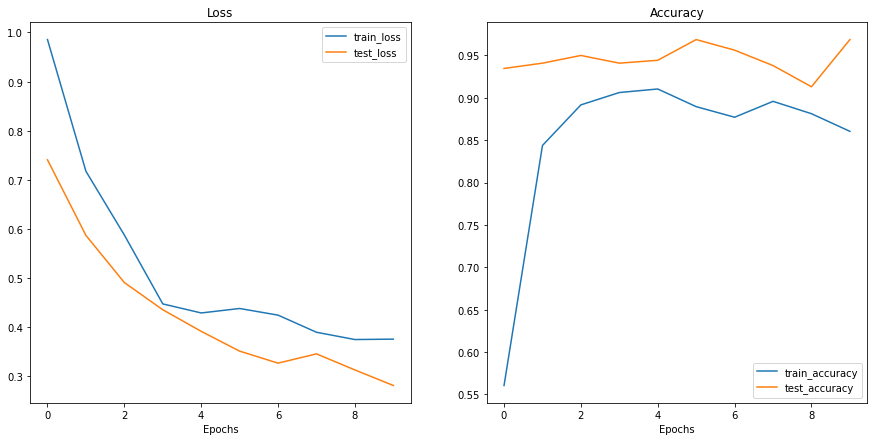

In [14]:
from helper_functions import plot_loss_curves

plot_loss_curves(effnetb2_results)

很棒！

这组 loss 曲线非常漂亮。

看起来模型已经表现不错；如果想进一步提升，可能可以适当延长训练时间，并加入一些 [data augmentation](https://www.learnpytorch.io/04_pytorch_custom_datasets/#6-other-forms-of-transforms-data-augmentation)（以降低长训练带来的潜在过拟合风险）。

### 3.5 保存 EffNetB2 特征提取器

现在我们已经得到一个表现不错的训练模型，把它保存到文件，方便后续加载和使用。

保存模型可以继续使用 [05. PyTorch Going Modular section 5](https://www.learnpytorch.io/05_pytorch_going_modular/#5-creating-a-function-to-save-the-model-utilspy) 中实现的 [`utils.save_model()`](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/going_modular/going_modular/utils.py)。

我们把 `target_dir` 设为 `"models"`，`model_name` 设为 `"09_pretrained_effnetb2_feature_extractor_pizza_steak_sushi_20_percent.pth"`（名字有点长，但信息很完整）。

In [ ]:
from going_modular.going_modular import utils

# 保存模型
utils.save_model(model=effnetb2,
                 target_dir="models",
                 model_name="09_pretrained_effnetb2_feature_extractor_pizza_steak_sushi_20_percent.pth")

[INFO] Saving model to: models/09_pretrained_effnetb2_feature_extractor_pizza_steak_sushi_20_percent.pth


### 3.6 检查 EffNetB2 特征提取器的模型大小

由于 FoodVision Mini 部署目标之一是**速度**（约 30FPS 或更高），我们先看一下模型体积。

为什么要看体积？

虽然并非绝对规律，但模型大小通常会影响推理速度。

也就是说，参数越多，通常意味着计算操作越多，而每一步操作都需要计算资源。

In [ ]:
from pathlib import Path

# 获取模型字节大小并转换为 MB
pretrained_effnetb2_model_size = Path("models/09_pretrained_effnetb2_feature_extractor_pizza_steak_sushi_20_percent.pth").stat().st_size // (1024*1024) # 通过除法将字节近似换算为 MB
print(f"Pretrained EffNetB2 feature extractor model size: {pretrained_effnetb2_model_size} MB")

Pretrained EffNetB2 feature extractor model size: 29 MB


### 3.7 汇总 EffNetB2 特征提取器统计信息

我们已经拿到 EffNetB2 的若干指标（如 test loss、test accuracy、模型大小），不如把它们统一放进一个字典，便于后面和 ViT 特征提取器比较。

另外我们再多算一个指标：参数总量。

做法是统计 `effnetb2.parameters()` 中元素（patterns/weights）数量。每个参数的元素数可通过 [`torch.numel()`](https://pytorch.org/docs/stable/generated/torch.numel.html)（即 "number of elements"）获取。

In [ ]:
# 统计 EffNetB2 参数总量
effnetb2_total_params = sum(torch.numel(param) for param in effnetb2.parameters())
effnetb2_total_params

7705221

非常好！

现在把这些信息汇总成一个字典，方便后续比较。

In [ ]:
# 创建 EffNetB2 统计字典
effnetb2_stats = {"test_loss": effnetb2_results["test_loss"][-1],
                  "test_acc": effnetb2_results["test_acc"][-1],
                  "number_of_parameters": effnetb2_total_params,
                  "model_size (MB)": pretrained_effnetb2_model_size}
effnetb2_stats

{'test_loss': 0.28128674924373626,
 'test_acc': 0.96875,
 'number_of_parameters': 7705221,
 'model_size (MB)': 29}

太棒了！

看起来 EffNetB2 模型准确率已经超过 95%。

目标 1：95%+ 准确率，达成！

## 4. 创建 ViT 特征提取器

继续推进 FoodVision Mini 的建模实验。

这次我们来创建 ViT 特征提取器。

整体流程与 EffNetB2 特征提取器基本一致，只是把 [`torchvision.models.efficientnet_b2()`](https://pytorch.org/vision/stable/models/generated/torchvision.models.efficientnet_b2.html#efficientnet-b2) 换成 [`torchvision.models.vit_b_16()`](https://pytorch.org/vision/stable/models/generated/torchvision.models.vit_b_16.html#torchvision.models.vit_b_16)。

我们先写一个 `create_vit_model()` 函数，结构会和 `create_effnetb2_model()` 很像，只不过返回的是 ViT 特征提取器及其 transforms。

另一个小区别是：`torchvision.models.vit_b_16()` 的输出层叫 `heads`，而不是 `classifier`。

In [ ]:
# 查看 ViT 的 heads 层
vit = torchvision.models.vit_b_16()
vit.heads

Sequential(
  (head): Linear(in_features=768, out_features=1000, bias=True)
)

明确这一点后，所需拼图就齐了。

In [ ]:
def create_vit_model(num_classes:int=3, 
                     seed:int=42):
    """创建 ViT-B/16 特征提取器模型及其 transforms。

    Args:
        num_classes (int, optional): 目标类别数。默认为 3。
        seed (int, optional): 输出层随机种子。默认为 42。

    Returns:
        model (torch.nn.Module): ViT-B/16 特征提取器模型。
        transforms (torchvision.transforms): ViT-B/16 图像 transforms。
    """
    # 创建 ViT_B_16 预训练权重、transforms 与模型
    weights = torchvision.models.ViT_B_16_Weights.DEFAULT
    transforms = weights.transforms()
    model = torchvision.models.vit_b_16(weights=weights)

    # 冻结模型全部层
    for param in model.parameters():
        param.requires_grad = False

    # 按任务需求替换分类头（该层可训练）
    torch.manual_seed(seed)
    model.heads = nn.Sequential(nn.Linear(in_features=768, # 保持与原模型一致
                                          out_features=num_classes)) # 更新为目标类别数
    
    return model, transforms

ViT 特征提取器创建函数已经准备好！

我们来测试一下。

In [ ]:
# 创建 ViT 模型与 transforms
vit, vit_transforms = create_vit_model(num_classes=3,
                                       seed=42)

没有报错，很棒！

现在用 `torchinfo.summary()` 看一份清晰的 ViT 模型摘要。

In [ ]:
from torchinfo import summary

# # 打印 ViT 特征提取器模型摘要（取消注释可查看完整输出）
# 如需查看摘要请取消下一行注释：summary(vit, 
#         输入尺寸=(1, 3, 224, 224),
#         列名字段=["input_size", "output_size", "num_params", "trainable"],
#         列宽=20,
#         行设置=["var_names"])

<img src="https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/09-vit-feature-extractor-3-classes.png" width=900 alt="3 类输出的 ViT 特征提取器"/>

和 EffNetB2 特征提取器一样，ViT 的基础层被冻结，输出层已按任务需求定制！

不过你注意到一个明显差异了吗？

ViT 的参数量比 EffNetB2 **大得多**。这点很可能会在后面比较速度与性能时体现出来。

### 4.1 为 ViT 创建 DataLoader

ViT 模型就绪后，接下来给它创建 `DataLoader`。

方法和 EffNetB2 基本一致，只是改用 `vit_transforms`，把图像转换成 ViT 训练时所用的输入格式。

In [ ]:
# 设置 ViT DataLoader
from going_modular.going_modular import data_setup
train_dataloader_vit, test_dataloader_vit, class_names = data_setup.create_dataloaders(train_dir=train_dir,
                                                                                       test_dir=test_dir,
                                                                                       transform=vit_transforms,
                                                                                       batch_size=32)

### 4.2 训练 ViT 特征提取器

你知道现在该做什么了……

……没错，训练时间到（配上 [Closing Time](https://youtu.be/xGytDsqkQY8) 的旋律）。

我们用 `engine.train()` 训练 ViT 特征提取器 10 个 epoch；优化器用 `torch.optim.Adam()`，学习率 `1e-3`；损失函数用 `torch.nn.CrossEntropyLoss()`。

训练前会调用 `set_seeds()`，尽量提高结果可复现性。

In [ ]:
from going_modular.going_modular import engine

# 设置优化器
optimizer = torch.optim.Adam(params=vit.parameters(),
                             lr=1e-3)
# 设置损失函数
loss_fn = torch.nn.CrossEntropyLoss()

# 设置随机种子并训练 ViT 模型（保证可复现）
set_seeds()
vit_results = engine.train(model=vit,
                           train_dataloader=train_dataloader_vit,
                           test_dataloader=test_dataloader_vit,
                           epochs=10,
                           optimizer=optimizer,
                           loss_fn=loss_fn,
                           device=device)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.7023 | train_acc: 0.7500 | test_loss: 0.2714 | test_acc: 0.9290
Epoch: 2 | train_loss: 0.2531 | train_acc: 0.9104 | test_loss: 0.1669 | test_acc: 0.9602
Epoch: 3 | train_loss: 0.1766 | train_acc: 0.9542 | test_loss: 0.1270 | test_acc: 0.9693
Epoch: 4 | train_loss: 0.1277 | train_acc: 0.9625 | test_loss: 0.1072 | test_acc: 0.9722
Epoch: 5 | train_loss: 0.1163 | train_acc: 0.9646 | test_loss: 0.0950 | test_acc: 0.9784
Epoch: 6 | train_loss: 0.1270 | train_acc: 0.9375 | test_loss: 0.0830 | test_acc: 0.9722
Epoch: 7 | train_loss: 0.0899 | train_acc: 0.9771 | test_loss: 0.0844 | test_acc: 0.9784
Epoch: 8 | train_loss: 0.0928 | train_acc: 0.9812 | test_loss: 0.0759 | test_acc: 0.9722
Epoch: 9 | train_loss: 0.0933 | train_acc: 0.9792 | test_loss: 0.0729 | test_acc: 0.9784
Epoch: 10 | train_loss: 0.0662 | train_acc: 0.9833 | test_loss: 0.0642 | test_acc: 0.9847


### 4.3 查看 ViT 的 loss 曲线

好的，ViT 训练完成，来可视化看看 loss 曲线。

> **Note:** 理想 loss 曲线的判断标准，可回看 [04. PyTorch Custom Datasets section 8](https://www.learnpytorch.io/04_pytorch_custom_datasets/#8-what-should-an-ideal-loss-curve-look-like)。

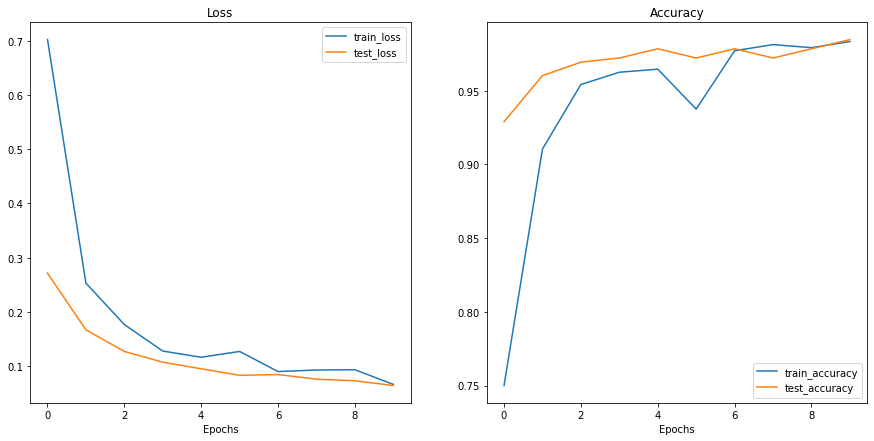

In [25]:
from helper_functions import plot_loss_curves

plot_loss_curves(vit_results)

太好了！

这组曲线非常不错。和 EffNetB2 一样，ViT 也可能受益于更长训练，或者加入 [data augmentation](https://www.learnpytorch.io/04_pytorch_custom_datasets/#6-other-forms-of-transforms-data-augmentation)（帮助抑制过拟合）。

### 4.4 保存 ViT 特征提取器

ViT 当前表现很出色！

把它保存到文件里，后面就能随时加载复用。

我们继续使用 [05. PyTorch Going Modular section 5](https://www.learnpytorch.io/05_pytorch_going_modular/#5-creating-a-function-to-save-the-model-utilspy) 中创建的 `utils.save_model()`。

In [ ]:
# 保存模型
from going_modular.going_modular import utils

utils.save_model(model=vit,
                 target_dir="models",
                 model_name="09_pretrained_vit_feature_extractor_pizza_steak_sushi_20_percent.pth")

[INFO] Saving model to: models/09_pretrained_vit_feature_extractor_pizza_steak_sushi_20_percent.pth


### 4.5 检查 ViT 特征提取器大小

由于我们要从多个维度比较 EffNetB2 与 ViT，接下来也查看 ViT 的模型体积。

要获取模型字节大小，可用 Python 的 `pathlib.Path.stat("path_to_model").st_size`，再除以 `(1024*1024)` 近似换算为 MB。

In [ ]:
from pathlib import Path

# 获取模型字节大小并转换为 MB
pretrained_vit_model_size = Path("models/09_pretrained_vit_feature_extractor_pizza_steak_sushi_20_percent.pth").stat().st_size // (1024*1024) # 通过除法将字节近似换算为 MB
print(f"Pretrained ViT feature extractor model size: {pretrained_vit_model_size} MB")

Pretrained ViT feature extractor model size: 327 MB


嗯，ViT 特征提取器的体积和 EffNetB2 相比如何？

我们马上在整体模型特征对比中看到答案。

### 4.6 汇总 ViT 特征提取器统计信息

把 ViT 的关键统计信息也整理出来。

虽然在上面的 summary 已经看到了参数规模，但这里我们仍显式计算参数总数。

In [ ]:
# 统计 ViT 参数总量
vit_total_params = sum(torch.numel(param) for param in vit.parameters())
vit_total_params

85800963

哇，这比 EffNetB2 多了不少！

> **Note:** 参数量（weights/patterns）更大通常意味着模型具备更高学习容量（capacity），但是否真正用上这部分容量，还取决于数据与训练设置。这里 EffNetB2 有 7,705,221 个参数，而 ViT 有 85,800,963（约 11.1 倍）。因此可推测 ViT 在数据更充分时潜在学习能力更强；但这种容量提升通常伴随更大模型体积和更长推理时间。

现在我们把 ViT 的重要指标也放到字典里。

In [ ]:
# 创建 ViT 统计字典
vit_stats = {"test_loss": vit_results["test_loss"][-1],
             "test_acc": vit_results["test_acc"][-1],
             "number_of_parameters": vit_total_params,
             "model_size (MB)": pretrained_vit_model_size}

vit_stats

{'test_loss': 0.06418210905976593,
 'test_acc': 0.984659090909091,
 'number_of_parameters': 85800963,
 'model_size (MB)': 327}

不错！看起来 ViT 准确率也达到了 95% 以上。

## 5. 用已训练模型做预测并计时

我们现在有两个训练好的模型，而且表现都不错。

接下来不如测试它们做“真实工作”的能力？

也就是：看看它们在推理（inference）时的表现。

我们已经知道两者在测试集上准确率都超过 95%，但它们到底有多快？

如果 FoodVision Mini 要部署到移动端，让用户拍食物照片实时识别，我们希望预测尽量接近实时（约 30FPS）。

这也是我们的第二条标准：模型要够快。

为了测出每个模型的推理时长，我们会写一个 `pred_and_store()` 函数，逐张遍历测试集图片并执行预测。

同时记录每张图的预测耗时，并把结果按常见格式存储：字典列表（list of dicts）。列表里每个元素是一条预测结果字典。

> **Note:** 我们按“单张”计时，而不是按 batch 计时，因为模型部署后通常一次只预测一张图：用户拍一张，模型就推一张。

既然我们要在整个测试集上跑预测，先拿到所有测试图片路径列表。

这里用 Python 的 [`pathlib.Path("target_dir").glob("*/*.jpg"))`](https://docs.python.org/3/library/pathlib.html#basic-use) 来查找目标目录下所有 `.jpg` 路径（也就是我们的测试图片）。

In [ ]:
from pathlib import Path

# 获取所有测试集图像路径
print(f"[INFO] Finding all filepaths ending with '.jpg' in directory: {test_dir}")
test_data_paths = list(Path(test_dir).glob("*/*.jpg"))
test_data_paths[:5]

[INFO] Finding all filepaths ending with '.jpg' in directory: data/pizza_steak_sushi_20_percent/test


[PosixPath('data/pizza_steak_sushi_20_percent/test/steak/831681.jpg'),
 PosixPath('data/pizza_steak_sushi_20_percent/test/steak/3100563.jpg'),
 PosixPath('data/pizza_steak_sushi_20_percent/test/steak/2752603.jpg'),
 PosixPath('data/pizza_steak_sushi_20_percent/test/steak/39461.jpg'),
 PosixPath('data/pizza_steak_sushi_20_percent/test/steak/730464.jpg')]

### 5.1 创建在测试集上批量预测的函数

现在测试图片路径列表有了，开始实现 `pred_and_store()`：

1. 创建函数，接收路径列表、训练好的 PyTorch 模型、图像 transforms、类别名列表和目标设备。
2. 创建空列表，用于存储预测字典（函数最终返回“每条预测一个字典”的列表）。
3. 遍历目标路径（步骤 4-14 都在循环中执行）。
4. 每次循环创建一个空字典，保存当前样本预测信息。
5. 获取样本路径与真实类别名（可从路径推断类别）。
6. 用 Python 的 [`timeit.default_timer()`](https://docs.python.org/3/library/timeit.html#timeit.default_timer) 开始计时。
7. 使用 [`PIL.Image.open(path)`](https://pillow.readthedocs.io/en/stable/reference/Image.html#functions) 打开图片。
8. 对图片做 transform，补 batch 维度，并发送到目标设备。
9. 将模型发送到目标设备并切换 `eval()` 推理模式。
10. 开启 [`torch.inference_mode()`](https://pytorch.org/docs/stable/generated/torch.inference_mode.html)，将图像送入模型，用 `torch.softmax()` 得到预测概率，用 `torch.argmax()` 得到预测标签。
11. 把预测概率与预测类别写入第 4 步的字典。并确保概率在 CPU 上，方便后续用 NumPy、pandas 等非 GPU 库分析。
12. 结束第 6 步计时，写入本次预测耗时。
13. 检查预测类别是否与第 5 步真实标签一致，把结果写入字典。
14. 将更新后的预测字典追加到第 2 步列表。
15. 返回预测字典列表。

步骤不少，但我们完全能搞定。

开始吧。

In [ ]:
import pathlib
import torch

from PIL import Image
from timeit import default_timer as timer 
from tqdm.auto import tqdm
from typing import List, Dict

# 1. 创建函数：返回包含样本路径、真实标签、预测结果、预测概率与预测耗时的字典列表
def pred_and_store(paths: List[pathlib.Path], 
                   model: torch.nn.Module,
                   transform: torchvision.transforms, 
                   class_names: List[str], 
                   device: str = "cuda" if torch.cuda.is_available() else "cpu") -> List[Dict]:
    
    # 2. 创建空列表保存预测字典
    pred_list = []
    
    # 3. 遍历目标路径
    for path in tqdm(paths):
        
        # 4. 为每个样本创建空字典
        pred_dict = {}

        # 5. 获取样本路径与真实类别名
        pred_dict["image_path"] = path
        class_name = path.parent.stem
        pred_dict["class_name"] = class_name
        
        # 6. 开始计时
        start_time = timer()
        
        # 7. 打开图像路径
        img = Image.open(path)
        
        # 8. 变换图像、添加 batch 维度并发送到目标设备
        transformed_image = transform(img).unsqueeze(0).to(device) 
        
        # 9. 将模型发送到目标设备并切换到 eval() 模式
        model.to(device)
        model.eval()
        
        # 10. 获取预测 logits、预测概率、预测标签与预测类别
        with torch.inference_mode():
            pred_logit = model(transformed_image) # 对目标样本执行推理
            pred_prob = torch.softmax(pred_logit, dim=1) # 将 logits 转为预测概率
            pred_label = torch.argmax(pred_prob, dim=1) # 将预测概率转为预测标签
            pred_class = class_names[pred_label.cpu()] # 将预测类别固定在 CPU 上

            # 11. 保证字典中的结果在 CPU 上（便于后续分析预测结果）
            pred_dict["pred_prob"] = round(pred_prob.unsqueeze(0).max().cpu().item(), 4)
            pred_dict["pred_class"] = pred_class
            
            # 12. 结束计时并计算单次预测耗时
            end_time = timer()
            pred_dict["time_for_pred"] = round(end_time-start_time, 4)

        # 13. 判断预测类别是否与真实标签一致
        pred_dict["correct"] = class_name == pred_class

        # 14. 将当前样本字典追加到结果列表
        pred_list.append(pred_dict)
    
    # 15. 返回预测字典列表
    return pred_list

太棒了！

这个函数写得很漂亮。

另外，`pred_and_store()` 作为一个通用预测与记录工具函数，非常适合放进 [`going_modular.going_modular.predictions.py`](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/going_modular/going_modular/predictions.py) 里复用。这个扩展你也可以尝试，思路可参考 [05. PyTorch Going Modular](https://www.learnpytorch.io/05_pytorch_going_modular/)。

### 5.2 使用 EffNetB2 做预测并计时

现在来实际测试 `pred_and_store()`！

先用 EffNetB2 在测试集上跑一遍预测，并重点注意两点：

1. **Device** - 我们把 `device` 固定为 `"cpu"`，因为模型部署后并不总能拿到 `"cuda"`（GPU）。
    * 在 CPU 上测试也能更真实地反映推理速度下限，因为 CPU 推理一般比 GPU 慢。
2. **Transforms** - `transform` 参数使用 `effnetb2_transforms`，确保图像预处理方式与 `effnetb2` 训练时一致。

In [ ]:
# 使用 EffNetB2 在测试集上做预测
effnetb2_test_pred_dicts = pred_and_store(paths=test_data_paths,
                                          model=effnetb2,
                                          transform=effnetb2_transforms,
                                          class_names=class_names,
                                          device="cpu") # 在 CPU 上进行预测

  0%|          | 0/150 [00:00<?, ?it/s]

很好！预测跑得很快。

我们先看前两条结果长什么样。

In [ ]:
# 查看前 2 条预测字典
effnetb2_test_pred_dicts[:2]

[{'image_path': PosixPath('data/pizza_steak_sushi_20_percent/test/steak/831681.jpg'),
  'class_name': 'steak',
  'pred_prob': 0.9293,
  'pred_class': 'steak',
  'time_for_pred': 0.0494,
  'correct': True},
 {'image_path': PosixPath('data/pizza_steak_sushi_20_percent/test/steak/3100563.jpg'),
  'class_name': 'steak',
  'pred_prob': 0.9534,
  'pred_class': 'steak',
  'time_for_pred': 0.0264,
  'correct': True}]

太好了！

看起来 `pred_and_store()` 工作正常。

借助“字典列表”这种结构，我们已经拿到了不少可分析信息。

接下来把它转成 pandas DataFrame 进一步查看。

In [ ]:
# 将 test_pred_dicts 转换为 DataFrame
import pandas as pd
effnetb2_test_pred_df = pd.DataFrame(effnetb2_test_pred_dicts)
effnetb2_test_pred_df.head()

,image_path,class_name,pred_prob,pred_class,time_for_pred,correct
0,data/pizza_steak_sushi_20_percent/test/steak/8...,steak,0.9293,steak,0.0494,True
1,data/pizza_steak_sushi_20_percent/test/steak/3...,steak,0.9534,steak,0.0264,True
2,data/pizza_steak_sushi_20_percent/test/steak/2...,steak,0.7532,steak,0.0256,True
3,data/pizza_steak_sushi_20_percent/test/steak/3...,steak,0.5935,steak,0.0263,True
4,data/pizza_steak_sushi_20_percent/test/steak/7...,steak,0.8959,steak,0.0269,True


很好！

你会发现这些预测字典非常容易转成结构化格式，后续分析会方便很多。

比如先看 EffNetB2 一共预测错了多少样本……

In [ ]:
# 统计预测正确数量
effnetb2_test_pred_df.correct.value_counts()

True     145
False      5
Name: correct, dtype: int64

150 张里只错了 5 张，已经很不错！

再看看平均单次预测耗时。

In [ ]:
# 计算平均单次预测耗时
effnetb2_average_time_per_pred = round(effnetb2_test_pred_df.time_for_pred.mean(), 4)
print(f"EffNetB2 average time per prediction: {effnetb2_average_time_per_pred} seconds")

EffNetB2 average time per prediction: 0.0269 seconds


嗯，这个平均预测耗时和我们“实时（约 30FPS，即 0.03 秒/张）”目标相比如何？

> **Note:** 预测耗时会因硬件不同而显著变化（例如本地 Intel i9 与 Google Colab CPU）。通常硬件越强、推理越快。以 EffNetB2 为例，我在本地深度学习 PC（Intel i9）上平均约 0.031 秒（接近实时）；而在 Google Colab（具体 CPU 不确定，可能是 [Intel(R) Xeon(R)](https://stackoverflow.com/questions/47805170/whats-the-hardware-spec-for-google-colaboratory)）上约 0.1396 秒（慢 3-4 倍）。

现在把 EffNetB2 的平均预测耗时加入 `effnetb2_stats` 字典。

In [ ]:
# 将 EffNetB2 的平均预测耗时加入统计字典
effnetb2_stats["time_per_pred_cpu"] = effnetb2_average_time_per_pred
effnetb2_stats

{'test_loss': 0.28128674924373626,
 'test_acc': 0.96875,
 'number_of_parameters': 7705221,
 'model_size (MB)': 29,
 'time_per_pred_cpu': 0.0269}

### 5.3 使用 ViT 做预测并计时

EffNetB2 跑完后，接下来对 ViT 做同样流程。

我们仍使用上面定义的 `pred_and_store()`，只是把模型换成 `vit`，预处理换成 `vit_transforms`。

同时继续固定 `device="cpu"`（你也可以扩展对比 CPU 与 GPU 推理耗时）。

In [ ]:
# 使用 ViT 特征提取器在测试集图像上生成预测字典列表
vit_test_pred_dicts = pred_and_store(paths=test_data_paths,
                                     model=vit,
                                     transform=vit_transforms,
                                     class_names=class_names,
                                     device="cpu")

  0%|          | 0/150 [00:00<?, ?it/s]

预测完成！

现在看前两条输出。

In [ ]:
# 查看测试集上 ViT 预测结果的前两条
vit_test_pred_dicts[:2]

[{'image_path': PosixPath('data/pizza_steak_sushi_20_percent/test/steak/831681.jpg'),
  'class_name': 'steak',
  'pred_prob': 0.9933,
  'pred_class': 'steak',
  'time_for_pred': 0.1313,
  'correct': True},
 {'image_path': PosixPath('data/pizza_steak_sushi_20_percent/test/steak/3100563.jpg'),
  'class_name': 'steak',
  'pred_prob': 0.9893,
  'pred_class': 'steak',
  'time_for_pred': 0.0638,
  'correct': True}]

很好！

和前面一样，ViT 的预测结果也是“字典列表”格式，所以可以很方便地转成 pandas DataFrame 做进一步分析。

In [ ]:
# 将 vit_test_pred_dicts 转为 DataFrame
import pandas as pd
vit_test_pred_df = pd.DataFrame(vit_test_pred_dicts)
vit_test_pred_df.head()

,image_path,class_name,pred_prob,pred_class,time_for_pred,correct
0,data/pizza_steak_sushi_20_percent/test/steak/8...,steak,0.9933,steak,0.1313,True
1,data/pizza_steak_sushi_20_percent/test/steak/3...,steak,0.9893,steak,0.0638,True
2,data/pizza_steak_sushi_20_percent/test/steak/2...,steak,0.9971,steak,0.0627,True
3,data/pizza_steak_sushi_20_percent/test/steak/3...,steak,0.7685,steak,0.0632,True
4,data/pizza_steak_sushi_20_percent/test/steak/7...,steak,0.9499,steak,0.0641,True


ViT 一共预测对了多少？

In [ ]:
# 统计预测正确数量
vit_test_pred_df.correct.value_counts()

True     148
False      2
Name: correct, dtype: int64

哇！

在“预测正确数”上，ViT 比 EffNetB2 略强，整个测试集只错了 2 张。

你也可以扩展做一个可视化：专门查看 ViT 的错分样本，分析误判原因。

接下来计算 ViT 的平均单次预测耗时。

In [ ]:
# 计算 ViT 模型平均单次预测耗时
vit_average_time_per_pred = round(vit_test_pred_df.time_for_pred.mean(), 4)
print(f"ViT average time per prediction: {vit_average_time_per_pred} seconds")

ViT average time per prediction: 0.0641 seconds


看起来它比 EffNetB2 的平均预测时间稍慢一些。那么在我们的第二条标准（速度）下，它表现如何？

先把这个值写入 `vit_stats`，后面和 EffNetB2 一起比较。

> **Note:** 平均预测耗时高度依赖硬件环境。比如 ViT 在我本地深度学习 PC（Intel i9 CPU）上的 CPU 推理平均约 0.0693-0.0777 秒；而在 Google Colab 上约 0.6766-0.7113 秒。

In [ ]:
# 将 ViT 在 CPU 上的平均预测耗时加入统计字典
vit_stats["time_per_pred_cpu"] = vit_average_time_per_pred
vit_stats

{'test_loss': 0.06418210905976593,
 'test_acc': 0.984659090909091,
 'number_of_parameters': 85800963,
 'model_size (MB)': 327,
 'time_per_pred_cpu': 0.0641}

## 6. 比较模型结果、预测时间与模型大小

两个最强候选模型都已经训练并评估完毕。

现在把它们正面比较一下。

我们先把 `effnetb2_stats` 和 `vit_stats` 两个字典转成 pandas DataFrame。

同时加一列模型名，并把测试准确率从小数转成百分比，方便阅读。

In [ ]:
# 将统计字典转换为 DataFrame
df = pd.DataFrame([effnetb2_stats, vit_stats])

# 添加模型名称列
df["model"] = ["EffNetB2", "ViT"]

# 将准确率转换为百分比
df["test_acc"] = round(df["test_acc"] * 100, 2)

df

,test_loss,test_acc,number_of_parameters,model_size (MB),time_per_pred_cpu,model
0,0.281287,96.88,7705221,29,0.0269,EffNetB2
1,0.064182,98.47,85800963,327,0.0641,ViT


很好！

看起来两者在测试准确率上很接近，但其他指标差异如何？

一种直观方式是：用 ViT 指标除以 EffNetB2 指标，得到各项比例。

我们新建一个 DataFrame 来展示。

In [ ]:
# 将 EffNetB2 平均预测耗时加入统计字典
effnetb2_stats["time_per_pred_cpu"] = effnetb2_average_time_per_pred
effnetb2_stats

,test_loss,test_acc,number_of_parameters,model_size (MB),time_per_pred_cpu
ViT to EffNetB2 ratios,0.228173,1.016412,11.135432,11.275862,2.3829


可以看到，ViT 在性能指标上（test loss 更低、test accuracy 更高）优于 EffNetB2，但代价是：

* 参数量超过 11 倍。
* 模型体积超过 11 倍。
* 单图预测耗时超过 2.5 倍。

这些权衡值不值？

如果算力无限，可能值得；但对于 FoodVision Mini 的目标场景（部署到较小设备，如手机），我们通常会优先选 EffNetB2：牺牲一点性能，换来更快推理和显著更小体积。

### 6.1 可视化速度与性能权衡

我们已经看到 ViT 在 test loss、test accuracy 上优于 EffNetB2。

但 EffNetB2 推理更快，且模型体积更小。

> **Note:** 推理时间也常称为 "latency"。

不如把这个事实可视化出来。

可以用 matplotlib 画图：

1. 基于比较 DataFrame 画散点图，对比 EffNetB2 与 ViT 的 `time_per_pred_cpu` 和 `test_acc`。
2. 添加标题、坐标轴标签，并调整字体大小提升可读性。
3. 在散点旁标注模型名。
4. 基于模型大小（`model_size (MB)`）生成图例。

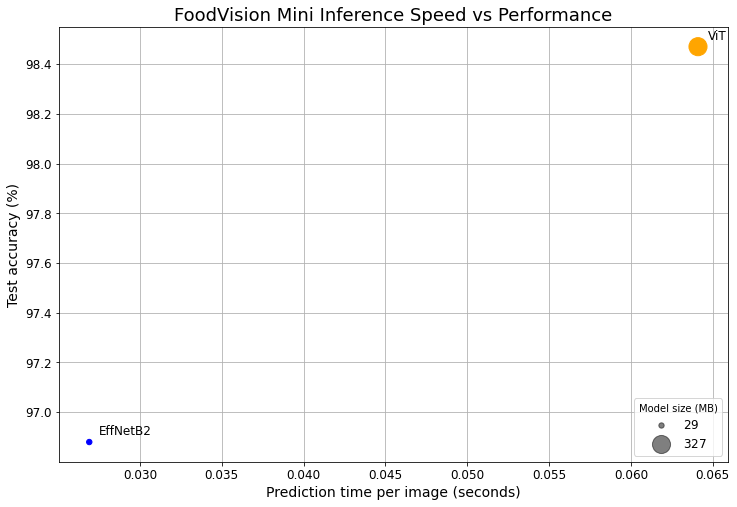

In [ ]:
# 1. 基于模型对比 DataFrame 画图
fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(data=df, 
                     x="time_per_pred_cpu", 
                     y="test_acc", 
                     c=["blue", "orange"], # 使用的颜色
                     s="model_size (MB)") # 点大小由模型大小决定

# 2. 添加标题、坐标标签并调整字体大小
ax.set_title("FoodVision Mini Inference Speed vs Performance", fontsize=18)
ax.set_xlabel("Prediction time per image (seconds)", fontsize=14)
ax.set_ylabel("Test accuracy (%)", fontsize=14)
ax.tick_params(axis='both', labelsize=12)
ax.grid(True)

# 3. 标注模型名称
for index, row in df.iterrows():
    ax.annotate(text=row["model"], # 注意：不同 Matplotlib 版本可能需使用 "s=..." 或 "text=..."，见：https://github.com/faustomorales/keras-ocr/issues/183#issuecomment-977733270 
                xy=(row["time_per_pred_cpu"]+0.0006, row["test_acc"]+0.03),
                size=12)

# 4. 基于模型大小创建图例
handles, labels = scatter.legend_elements(prop="sizes", alpha=0.5)
model_size_legend = ax.legend(handles, 
                              labels, 
                              loc="lower right", 
                              title="Model size (MB)",
                              fontsize=12)

# 保存图片
!mdkir images/
plt.savefig("images/09-foodvision-mini-inference-speed-vs-performance.jpg")

# 显示图片
plt.show()

很直观！

这张图清楚展示了**速度 vs 性能（speed vs performance）权衡**：通常更大、性能更强的深度模型（比如 ViT）推理耗时也更高（latency 更大）。

当然也有例外，而且相关研究一直在推动“大模型更快推理”。

很多时候会想直接部署“最准”的模型，但还应结合模型最终运行场景。

在我们的案例中，两者在 test loss/test accuracy 上差距并不夸张。

而我们当前更强调速度，因此先部署 EffNetB2 更合适：更快、占用更小。

> **Note:** 预测耗时会随硬件环境变化（如 Intel i9、Google Colab CPU 或 GPU）。因此部署前要明确并测试目标环境。像“模型最终在哪里运行？”“理想运行场景是什么？”这类问题，越早通过实验回答越好。

## 7. 用 Gradio 把 FoodVision Mini 变成可用应用

我们决定先部署 EffNetB2（后续也随时可以替换）。

那该怎么做？

机器学习模型有很多部署路径，各自适配不同场景（上面已经讨论过）。

这里我们聚焦一条可能是最快、也最有趣的上线路径。

那就是使用 [Gradio](https://gradio.app/)。

Gradio 是什么？

官网描述非常到位：

> Gradio 是快速演示机器学习模型的方式之一：通过友好的 Web 界面，让任何人都能在任何地方体验你的模型。

为什么要给模型做 demo？

因为测试集指标再好，也不等于真实世界表现一定好。

所以开始部署吧！

我们先按惯例用 `gr` 导入 Gradio；若未安装则先安装。

In [ ]:
# 导入/安装 Gradio
try:
    import gradio as gr
except: 
    !pip -q install gradio
    import gradio as gr
    
print(f"Gradio version: {gr.__version__}")

Gradio version: 3.1.4


Gradio 就绪！

接下来把 FoodVision Mini 做成 demo 应用。

### 7.1 Gradio 概览

Gradio 的整体思路和我们在课程里反复强调的一样：

什么是**输入（inputs）**，什么是**输出（outputs）**？

中间如何映射？

而这正是机器学习模型在做的事。

```
inputs -> ML model -> outputs
```

在 FoodVision Mini 场景中，输入是食物图片，模型是 EffNetB2，输出是类别（pizza、steak、sushi）。

```
images of food -> EffNetB2 -> outputs
```

当然，输入/输出范式可以迁移到几乎所有 ML 问题。

你的输入输出可能是以下任意组合：

* 图片
* 文本
* 视频
* 表格数据
* 音频
* 数值
* 以及更多

模型形态取决于输入输出定义。

Gradio 通过创建接口（[`gradio.Interface()`](https://gradio.app/docs/#interface-header)）来实现这个范式。

```
gradio.Interface(fn, inputs, outputs)
```

其中 `fn` 是一个 Python 函数，用于把 `inputs` 映射为 `outputs`。

<img src="https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/09-gradio-workflow.png" alt="Gradio 工作流：输入进入模型/函数后产出结果" width=900/>

*Gradio 的 `Interface` 非常适合快速搭建“输入 -> 模型/函数 -> 输出”流程。输入输出几乎可以是任意类型。比如输入 Tweets（文本）判断是否与机器学习相关，或 [输入文本提示词生成图像](https://huggingface.co/blog/stable_diffusion)。*

> **Note:** Gradio 提供大量输入/输出组件（Components），从图像、文本、数字到音频、视频等。详见 [Gradio Components documentation](https://gradio.app/docs/#components)。

### 7.2 创建输入到输出的映射函数

要用 Gradio 做 FoodVision Mini demo，我们需要一个把输入映射到输出的函数。

前面我们写过 `pred_and_store()`，它会对一组文件逐个预测并把结果存进字典列表。

现在我们写一个类似函数，但聚焦“单张图”预测：用 EffNetB2 对单图进行推理。

更具体地，我们希望函数接收一张图，完成预处理（transform），再用 EffNetB2 预测，最后返回预测类别（pred/pred label）和预测概率（pred prob）。

顺便也返回本次预测耗时：

```
input: image -> transform -> predict with EffNetB2 -> output: pred, pred prob, time taken
```

这个函数会作为 Gradio 接口中的 `fn` 参数。

首先确保 EffNetB2 在 CPU 上（这里我们先坚持 CPU-only 推理；如果有 GPU 也可以改）。

In [ ]:
# 将 EffNetB2 放到 CPU
effnetb2.to("cpu") 

# 检查设备
next(iter(effnetb2.parameters())).device

device(type='cpu')

现在创建 `predict()` 函数，复现上面的工作流。

In [ ]:
from typing import Tuple, Dict

def predict(img) -> Tuple[Dict, float]:
    """对输入图像做 transform 并预测，返回预测结果与耗时。
    """
    # 开始计时
    start_time = timer()
    
    # 对目标图像做 transform 并添加 batch 维度
    img = effnetb2_transforms(img).unsqueeze(0)
    
    # 将模型切到评估模式并开启推理模式
    effnetb2.eval()
    with torch.inference_mode():
        # 将图像送入模型，并把 logits 转成预测概率
        pred_probs = torch.softmax(effnetb2(img), dim=1)
    
    # 为每个类别创建“类别名: 概率”字典（Gradio 输出要求）
    pred_labels_and_probs = {class_names[i]: float(pred_probs[0][i]) for i in range(len(class_names))}
    
    # 计算预测耗时
    pred_time = round(timer() - start_time, 5)
    
    # 返回预测字典与预测耗时
    return pred_labels_and_probs, pred_time

非常好！

现在我们用测试集随机一张图跑一下，看看函数效果。

先获取测试目录所有图片路径，再随机挑一张。

然后用 [`PIL.Image.open()`](https://pillow.readthedocs.io/en/stable/reference/Image.html#functions) 打开该图。

最后把图片传入 `predict()` 函数。

In [ ]:
# 将 ViT 在 CPU 上的平均预测耗时加入统计字典
vit_stats["time_per_pred_cpu"] = vit_average_time_per_pred
vit_stats

[INFO] Predicting on image at path: data/pizza_steak_sushi_20_percent/test/pizza/3770514.jpg

Prediction label and probability dictionary: 
{'pizza': 0.9785208702087402, 'steak': 0.01169557310640812, 'sushi': 0.009783552028238773}
Prediction time: 0.027 seconds


很好！

多运行几次上面的单元，你会看到 EffNetB2 对各类别给出的概率会变化，同时也能观察每次预测耗时。

### 7.3 创建示例图片列表

`predict()` 已经打通了 inputs -> transform -> ML model -> outputs 流程。

这正是 Gradio demo 所需核心链路。

在真正创建 demo 前，我们再补一个东西：示例列表（examples）。

Gradio 的 [`Interface`](https://gradio.app/docs/#interface) 提供可选参数 `examples`（`gradio.Interface(examples=List[Any])`）。

这个参数的格式是“列表中的列表”（list of lists）。

所以我们创建一个 list of lists，内部放测试集随机图片路径。

3 张示例就够了。

In [ ]:
# 创建 Gradio demo 的示例输入列表
example_list = [[str(filepath)] for filepath in random.sample(test_data_paths, k=3)]
example_list

[['data/pizza_steak_sushi_20_percent/test/sushi/804460.jpg'],
 ['data/pizza_steak_sushi_20_percent/test/steak/746921.jpg'],
 ['data/pizza_steak_sushi_20_percent/test/steak/2117351.jpg']]

完美！

在 Gradio demo 里，这些会作为示例输入，用户无需上传自己的数据也能快速体验效果。

### 7.4 构建 Gradio 界面

现在把所有拼图合起来，让 FoodVision Mini demo 真正跑起来！

我们用 Gradio 复现这条工作流：

```
input: image -> transform -> predict with EffNetB2 -> output: pred, pred prob, time taken
```

可通过 [`gradio.Interface()`](https://gradio.app/docs/#interface) 并设置以下参数：

* `fn` - 把 `inputs` 映射为 `outputs` 的 Python 函数，本例使用 `predict()`。
* `inputs` - 界面的输入组件，如 [`gradio.Image()`](https://gradio.app/docs/#image) 或 `"image"`。 
* `outputs` - 输入经过 `fn` 后的输出组件，如 [`gradio.Label()`](https://gradio.app/docs/#label)（类别与概率）与 [`gradio.Number()`](https://gradio.app/docs/#number)（预测耗时）。
    * **Note:** Gradio 提供大量内置输入输出组件，统称为 ["Components"](https://gradio.app/docs/#components)。
* `examples` - demo 展示用示例列表。
* `title` - demo 标题文本。
* `description` - demo 描述文本。
* `article` - demo 底部参考说明。

创建好 `gr.Interface()` 实例后，通过 [`gradio.Interface().launch()`](https://gradio.app/docs/#launch-header)（即 `demo.launch()`）就能启动应用。

很简单！

In [ ]:
import gradio as gr

# 创建 title、description 和 article 字符串
title = "FoodVision Mini 🍕🥩🍣"
description = "An EfficientNetB2 feature extractor computer vision model to classify images of food as pizza, steak or sushi."
article = "Created at [09. PyTorch Model Deployment](https://www.learnpytorch.io/09_pytorch_model_deployment/)."

# 创建 Gradio demo
demo = gr.Interface(fn=predict, # 将输入映射到输出的函数
                    inputs=gr.Image(type="pil"), # 输入组件
                    outputs=[gr.Label(num_top_classes=3, label="Predictions"), # 输出组件
                             gr.Number(label="Prediction time (s)")], # 函数有两个输出，因此这里也有两个输出组件
                    examples=example_list, 
                    title=title,
                    description=description,
                    article=article)

# 启动 demo
demo.launch(debug=False, # 是否在本地打印错误
            share=True) # 是否生成可公开分享的 URL

Running on local URL:  http://127.0.0.1:7860/
Running on public URL: https://27541.gradio.app

This share link expires in 72 hours. For free permanent hosting, check out Spaces: https://huggingface.co/spaces


(<gradio.routes.App at 0x7f122dd0f0d0>,
 'http://127.0.0.1:7860/',
 'https://27541.gradio.app')

<img src="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/images/09-gradio-running-in-google-colab-and-in-browser.gif" alt="Gradio 演示：在 Google Colab 与网页端运行" width=750/>

*FoodVision Mini 的 Gradio demo 在 Google Colab 与浏览器中运行示意（在 Colab 运行时生成的链接通常仅保留 72 小时）。你也可以看 [Hugging Face Spaces 上的永久在线版本](https://huggingface.co/spaces/mrdbourke/foodvision_mini)。*

太棒了！！！

FoodVision Mini 现在已经变成了一个任何人都可以交互体验的应用界面。

如果你在 `launch()` 里设置 `share=True`，Gradio 会给出一个可分享链接（例如 `https://123XYZ.gradio.app`，此处仅示例，通常会过期），有效期约 72 小时。

这个链接会代理到你当前启动的 Gradio 界面。

如果想长期托管，可以把 Gradio 应用部署到 [Hugging Face Spaces](https://huggingface.co/spaces) 或任何可运行 Python 的平台。

## 8. 把 FoodVision Mini Gradio Demo 整理成可部署应用

我们已经看到 FoodVision Mini 在 Gradio demo 中跑起来了。

但如果想分享给朋友呢？

虽然可以直接发 Gradio 临时链接，但它只会保留约 72 小时。

要让 FoodVision Mini 更长期可用，我们可以把它打包成应用并上传到 [Hugging Face Spaces](https://huggingface.co/spaces/launch)。

### 8.1 什么是 Hugging Face Spaces？

Hugging Face Spaces 是一个托管和分享机器学习应用的平台。

做 demo 是展示与验证成果的最佳方式之一。

Spaces 正好能支持这件事。

你可以把 Hugging Face 理解成机器学习领域的 GitHub。

如果优质 GitHub 作品集展示的是编码能力，那么优质 Hugging Face 作品集展示的是机器学习工程能力。

> **Note:** 当然也可以把 Gradio 应用部署到 Google Cloud、AWS 等云平台；这里选择 Hugging Face Spaces，主要因为它上手简单且在 ML 社区采用广泛。

### 8.2 已部署 Gradio 应用的目录结构

要上传 Gradio demo，建议把所有相关文件放在同一目录。

例如路径 `demos/foodvision_mini/`，文件结构如下：

```
demos/
└── foodvision_mini/
    ├── 09_pretrained_effnetb2_feature_extractor_pizza_steak_sushi_20_percent.pth
    ├── app.py
    ├── examples/
    │   ├── example_1.jpg
    │   ├── example_2.jpg
    │   └── example_3.jpg
    ├── model.py
    └── requirements.txt
```

其中：

* `09_pretrained_effnetb2_feature_extractor_pizza_steak_sushi_20_percent.pth` 是训练好的 PyTorch 模型文件。
* `app.py` 放 Gradio 应用代码（与前面启动 demo 的逻辑一致）。
    * **Note:** 在 Hugging Face Spaces 中，默认入口文件名是 `app.py`（可在设置中修改）。
* `examples/` 放 Gradio 示例图片。
* `model.py` 放模型定义与对应 transforms。
* `requirements.txt` 放应用依赖，如 `torch`、`torchvision`、`gradio`。

为什么这样组织？

因为这是一个非常简洁、容易起步的结构。

我们的核心策略依旧是：*experiment, experiment, experiment!*

越快跑通小实验，后续大实验质量越高。

我们会按上面的结构来重建；你也可以直接查看线上版本：

* [FoodVision Mini 🍕🥩🍣 在线 Gradio demo](https://huggingface.co/spaces/mrdbourke/foodvision_mini)。
* [FoodVision Mini 在 Hugging Face Spaces 的文件结构](https://huggingface.co/spaces/mrdbourke/foodvision_mini/tree/main)。

### 8.3 创建 `demos` 目录用于存放 FoodVision Mini 应用文件

首先创建 `demos/` 目录，集中存放 FoodVision Mini 应用文件。

可用 Python 的 [`pathlib.Path("path_to_dir")`](https://docs.python.org/3/library/pathlib.html#basic-use) 定义目录路径，再用 [`pathlib.Path("path_to_dir").mkdir()`](https://docs.python.org/3/library/pathlib.html#pathlib.Path.mkdir) 创建目录。

In [ ]:
import shutil
from pathlib import Path

# 创建 FoodVision Mini demo 路径
foodvision_mini_demo_path = Path("demos/foodvision_mini/")

# 删除可能已存在的文件并创建新目录
if foodvision_mini_demo_path.exists():
    shutil.rmtree(foodvision_mini_demo_path)
# 如果目录不存在，也正常创建
foodvision_mini_demo_path.mkdir(parents=True, 
                                exist_ok=True)
    
# 检查目录内容
!ls demos/foodvision_mini/

### 8.4 创建示例图片目录

目录建好后，先补充示例图片。

从测试集选 3 张图就够了。

步骤如下：

1. 在 `demos/foodvision_mini` 下创建 `examples/` 目录。
2. 从测试集随机挑 3 张图并收集路径。
3. 把这 3 张图复制到 `demos/foodvision_mini/examples/`。

In [54]:
import shutil
from pathlib import Path

# 1. Create an examples directory
foodvision_mini_examples_path = foodvision_mini_demo_path / "examples"
foodvision_mini_examples_path.mkdir(parents=True, exist_ok=True)

# 2. Collect three random test dataset image paths
foodvision_mini_examples = [Path('data/pizza_steak_sushi_20_percent/test/sushi/592799.jpg'),
                            Path('data/pizza_steak_sushi_20_percent/test/steak/3622237.jpg'),
                            Path('data/pizza_steak_sushi_20_percent/test/pizza/2582289.jpg')]

# 3. Copy the three random images to the examples directory
for example in foodvision_mini_examples:
    destination = foodvision_mini_examples_path / example.name
    print(f"[INFO] Copying {example} to {destination}")
    shutil.copy2(src=example, dst=destination)

[INFO] Copying data/pizza_steak_sushi_20_percent/test/sushi/592799.jpg to demos/foodvision_mini/examples/592799.jpg
[INFO] Copying data/pizza_steak_sushi_20_percent/test/steak/3622237.jpg to demos/foodvision_mini/examples/3622237.jpg
[INFO] Copying data/pizza_steak_sushi_20_percent/test/pizza/2582289.jpg to demos/foodvision_mini/examples/2582289.jpg


为了确认示例已就位，我们可以先用 [`os.listdir()`](https://docs.python.org/3/library/os.html#os.listdir) 列出 `demos/foodvision_mini/examples/` 目录内容，再把路径整理成“列表中的列表”格式（兼容 Gradio [`gradio.Interface()`](https://gradio.app/docs/#interface) 的 `examples` 参数）。

In [ ]:
import os

# 以“列表套列表”形式收集示例图片路径
example_list = [["examples/" + example] for example in os.listdir(foodvision_mini_examples_path)]
example_list

[['examples/3622237.jpg'], ['examples/592799.jpg'], ['examples/2582289.jpg']]

### 8.5 将训练好的 EffNetB2 模型移动到 demo 目录

前面我们把 FoodVision Mini 的 EffNetB2 特征提取器模型保存在 `models/09_pretrained_effnetb2_feature_extractor_pizza_steak_sushi_20_percent.pth`。

为了避免重复存储，直接把模型移动到 `demos/foodvision_mini`。

可以用 Python 的 [`shutil.move()`](https://docs.python.org/3/library/shutil.html#shutil.move)，传入 `src`（源路径）和 `dst`（目标路径）。

In [ ]:
import shutil

# 创建目标模型源路径
effnetb2_foodvision_mini_model_path = "models/09_pretrained_effnetb2_feature_extractor_pizza_steak_sushi_20_percent.pth"

# 创建目标模型目标路径
effnetb2_foodvision_mini_model_destination = foodvision_mini_demo_path / effnetb2_foodvision_mini_model_path.split("/")[1]

# 尝试移动文件
try:
    print(f"[INFO] Attempting to move {effnetb2_foodvision_mini_model_path} to {effnetb2_foodvision_mini_model_destination}")
    
    # 移动模型
    shutil.move(src=effnetb2_foodvision_mini_model_path, 
                dst=effnetb2_foodvision_mini_model_destination)
    
    print(f"[INFO] Model move complete.")

# 如果模型已被移动，检查目标路径是否存在
except:
    print(f"[INFO] No model found at {effnetb2_foodvision_mini_model_path}, perhaps its already been moved?")
    print(f"[INFO] Model exists at {effnetb2_foodvision_mini_model_destination}: {effnetb2_foodvision_mini_model_destination.exists()}")

[INFO] Attempting to move models/09_pretrained_effnetb2_feature_extractor_pizza_steak_sushi_20_percent.pth to demos/foodvision_mini/09_pretrained_effnetb2_feature_extractor_pizza_steak_sushi_20_percent.pth
[INFO] Model move complete.


### 8.6 将 EffNetB2 模型封装为 Python 脚本（`model.py`）

当前模型 `state_dict` 已保存到 `demos/foodvision_mini/09_pretrained_effnetb2_feature_extractor_pizza_steak_sushi_20_percent.pth`。

后续加载时可通过 `model.load_state_dict()` + `torch.load()`。

> **Note:** 如果你想复习 PyTorch 中模型（或 `state_dict`）保存加载，可回看 [01. PyTorch Workflow Fundamentals section 5](https://www.learnpytorch.io/01_pytorch_workflow/#5-saving-and-loading-a-pytorch-model) 或 PyTorch 官方教程 [What is a `state_dict` in PyTorch?](https://pytorch.org/tutorials/recipes/recipes/what_is_state_dict.html)。

但在加载之前，我们需要一个可实例化的 `model` 定义。

为保持模块化，我们创建 `model.py`，放入在 [section 3.1](https://www.learnpytorch.io/09_pytorch_model_deployment/#31-creating-a-function-to-make-an-effnetb2-feature-extractor) 写的 `create_effnetb2_model()`。

这样就能在**另一个**脚本（后面的 `app.py`）中导入该函数，创建 EffNetB2 实例并得到对应 transforms。

和 [05. PyTorch Going Modular](https://www.learnpytorch.io/05_pytorch_going_modular/) 一样，这里继续使用 `%%writefile path/to/file` 把代码单元写入文件。

In [ ]:
%%writefile demos/foodvision_mini/model.py
import torch
import torchvision

from torch import nn


def create_effnetb2_model(num_classes:int=3, 
                          seed:int=42):
    """创建 EfficientNetB2 特征提取器模型及其 transforms。

    Args:
        num_classes (int, optional): 分类头中的类别数。
            默认为 3。
        seed (int, optional): 随机种子。默认为 42。

    Returns:
        model (torch.nn.Module): EffNetB2 特征提取器模型。
        transforms (torchvision.transforms): EffNetB2 图像 transforms。
    """
    # 创建 EffNetB2 预训练权重、transforms 与模型
    weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT
    transforms = weights.transforms()
    model = torchvision.models.efficientnet_b2(weights=weights)

    # 冻结基础模型全部层
    for param in model.parameters():
        param.requires_grad = False

    # 设置随机种子并替换分类头（确保可复现）
    torch.manual_seed(seed)
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(in_features=1408, out_features=num_classes),
    )
    
    return model, transforms

Writing demos/foodvision_mini/model.py


### 8.7 将 FoodVision Mini Gradio 应用封装为 Python 脚本（`app.py`）

现在我们已有 `model.py`，也有可加载的模型 `state_dict` 路径。

接下来构建 `app.py`。

之所以命名为 `app.py`，是因为 Hugging Face Space 默认会寻找并运行这个文件（当然可在设置里改）。

`app.py` 会把 demo 的核心拼图整合起来，主要分四部分：

1. **导入依赖与类别名设置** - 导入 demo 所需依赖、从 `model.py` 导入 `create_effnetb2_model()`，并设置 FoodVision Mini 类别名。 
2. **模型与 transforms 准备** - 创建 EffNetB2 实例与 transforms，再加载已保存权重。加载时在 [`torch.load()`](https://pytorch.org/docs/stable/generated/torch.load.html) 中设置 `map_location=torch.device("cpu")`，保证无论训练设备是什么，部署时都能映射到 CPU（否则“GPU 训练 -> CPU 部署”常报错）。
3. **预测函数** - Gradio `gradio.Interface()` 通过 `fn` 参数连接输入输出。这里沿用 [section 7.2](https://www.learnpytorch.io/09_pytorch_model_deployment/#72-creating-a-function-to-map-our-inputs-and-outputs) 的 `predict()`：输入图片 -> transforms 预处理 -> 模型预测。
    * **Note:** `examples` 可动态生成：`[["examples/" + example] for example in os.listdir("examples")]`。
4. **Gradio 应用主体** - 创建名为 `demo` 的 `gradio.Interface()`，连接输入、`predict()` 与输出，最后 `demo.launch()` 启动 FoodVision Mini demo。

In [ ]:
%%writefile demos/foodvision_mini/app.py
### 1. 导入依赖并设置类别名 ### 
import gradio as gr
import os
import torch

from model import create_effnetb2_model
from timeit import default_timer as timer
from typing import Tuple, Dict

# 设置类别名
class_names = ["pizza", "steak", "sushi"]

### 2. 准备模型与 transforms ###

# 创建 EffNetB2 模型
effnetb2, effnetb2_transforms = create_effnetb2_model(
    num_classes=3, # 也可使用 len(class_names)
 )

# 加载已保存权重
effnetb2.load_state_dict(
    torch.load(
        f="09_pretrained_effnetb2_feature_extractor_pizza_steak_sushi_20_percent.pth",
        map_location=torch.device("cpu"),  # 加载到 CPU
    )
)

### 3. 预测函数 ###

# 创建预测函数
def predict(img) -> Tuple[Dict, float]:
    """对输入图像做 transform 并预测，返回预测结果与耗时。
    """
    # 开始计时
    start_time = timer()
    
    # 对目标图像做 transform 并添加 batch 维度
    img = effnetb2_transforms(img).unsqueeze(0)
    
    # 将模型切到评估模式并开启推理模式
    effnetb2.eval()
    with torch.inference_mode():
        # 将图像送入模型，并把 logits 转成预测概率
        pred_probs = torch.softmax(effnetb2(img), dim=1)
    
    # 为每个类别创建“类别名: 概率”字典（Gradio 输出要求）
    pred_labels_and_probs = {class_names[i]: float(pred_probs[0][i]) for i in range(len(class_names))}
    
    # 计算预测耗时
    pred_time = round(timer() - start_time, 5)
    
    # 返回预测字典与预测耗时
    return pred_labels_and_probs, pred_time

### 4. Gradio 应用 ###

# 创建 title、description 和 article 字符串
title = "FoodVision Mini 🍕🥩🍣"
description = "An EfficientNetB2 feature extractor computer vision model to classify images of food as pizza, steak or sushi."
article = "Created at [09. PyTorch Model Deployment](https://www.learnpytorch.io/09_pytorch_model_deployment/)."

# 从 "examples/" 目录创建示例列表
example_list = [["examples/" + example] for example in os.listdir("examples")]

# 创建 Gradio demo
demo = gr.Interface(fn=predict, # 将输入映射到输出的函数
                    inputs=gr.Image(type="pil"), # 输入组件
                    outputs=[gr.Label(num_top_classes=3, label="Predictions"), # 输出组件
                             gr.Number(label="Prediction time (s)")], # 函数有两个输出，因此这里也有两个输出组件
                    # 从 "examples/" 目录创建示例列表
                    examples=example_list, 
                    title=title,
                    description=description,
                    article=article)

# 启动 demo
demo.launch()

Writing demos/foodvision_mini/app.py


### 8.8 为 FoodVision Mini 创建依赖文件（`requirements.txt`）

FoodVision Mini 应用最后一个必要文件是 [`requirements.txt`](https://learnpython.com/blog/python-requirements-file/)。

它是一个纯文本依赖清单。

当我们把 demo 部署到 Hugging Face Spaces 后，平台会读取该文件并安装依赖，应用才能正常运行。

好消息是这里只需 3 个依赖：

1. `torch==1.12.0`
2. `torchvision==0.13.0`
3. `gradio==3.1.4`

其中 `==1.12.0` 指定安装版本。

固定版本不是绝对必须，但这里先固定，避免未来破坏性更新导致应用失效（如果你发现问题，也欢迎在课程 [GitHub Issues](https://github.com/mrdbourke/pytorch-deep-learning/issues) 提反馈）。

In [59]:
%%writefile demos/foodvision_mini/requirements.txt
torch==1.12.0
torchvision==0.13.0
gradio==3.1.4

Writing demos/foodvision_mini/requirements.txt


很好！

现在部署 FoodVision Mini demo 所需文件已经全部就绪。

## 9. 将 FoodVision Mini 应用部署到 Hugging Face Spaces

FoodVision Mini demo 文件已经准备好了，接下来怎么让它在 Hugging Face Spaces 上跑起来？

上传到 Hugging Face Space（也叫 [Hugging Face Repository](https://huggingface.co/docs/hub/repositories-getting-started#getting-started-with-repositories)，类似 git 仓库）主要有两种方式：

1. [通过 Hugging Face 网页界面上传（最简单）](https://huggingface.co/docs/hub/repositories-getting-started#adding-files-to-a-repository-web-ui)。
2. [通过命令行/终端上传](https://huggingface.co/docs/hub/repositories-getting-started#terminal)。
    * **Bonus:** 还可以用 [`huggingface_hub` 库](https://huggingface.co/docs/huggingface_hub/index) 与 Hugging Face 交互，这也是不错的扩展方向。

两种都值得看看文档，这里我们采用第二种。

> **Note:** 想在 Hugging Face 托管内容，需要先 [注册一个免费账号](https://huggingface.co/join)。

### 9.1 下载 FoodVision Mini 应用文件

先查看 `demos/foodvision_mini` 中已经生成了哪些文件。

可以用 `!ls` 命令查看目标路径内容。

`ls` 是“列出目录”，前面的 `!` 表示在 shell 层执行命令。

In [60]:
!ls demos/foodvision_mini

09_pretrained_effnetb2_feature_extractor_pizza_steak_sushi_20_percent.pth
app.py
examples
model.py
requirements.txt


这些都是我们刚刚创建的文件！

为了上传到 Hugging Face，先把它们从 Google Colab（或你当前运行 notebook 的环境）下载下来。

做法是先打包成 zip：

```
zip -r ../foodvision_mini.zip * -x "*.pyc" "*.ipynb" "*__pycache__*" "*ipynb_checkpoints*"
```

参数说明：

* `zip` 表示把指定目录内容压缩打包。
* `-r` 表示递归遍历目标目录。
* `../foodvision_mini.zip` 是压缩包输出路径。
* `*` 表示当前目录下所有文件。
* `-x` 表示排除匹配到的文件。

在 Google Colab 中可以用 [`google.colab.files.download("demos/foodvision_mini.zip")`](https://colab.research.google.com/notebooks/io.ipynb) 下载。

这里用 `try/except` 包一下：若不在 Colab 环境，则提示手动下载。

来试试看！

In [ ]:
# 进入 foodvision_mini 目录并压缩，同时排除部分文件
!cd demos/foodvision_mini && zip -r ../foodvision_mini.zip * -x "*.pyc" "*.ipynb" "*__pycache__*" "*ipynb_checkpoints*"

# 下载打包后的 FoodVision Mini 应用（若在 Google Colab 中运行）
try:
    from google.colab import files
    files.download("demos/foodvision_mini.zip")
except:
    print("Not running in Google Colab, can't use google.colab.files.download(), please manually download.")

updating: 09_pretrained_effnetb2_feature_extractor_pizza_steak_sushi_20_percent.pth (deflated 8%)
updating: app.py (deflated 57%)
updating: examples/ (stored 0%)
updating: examples/3622237.jpg (deflated 0%)
updating: examples/592799.jpg (deflated 1%)
updating: examples/2582289.jpg (deflated 17%)
updating: model.py (deflated 56%)
updating: requirements.txt (deflated 4%)
Not running in Google Colab, can't use google.colab.files.download(), please manually download.


太好了！

看起来 `zip` 命令执行成功。

如果你在 Google Colab 中运行，这时浏览器应该会开始下载文件。

如果不是 Colab，也可以在课程 GitHub 的 [`demos/` 目录](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/demos) 看到 `foodvision_mini.zip` 等文件。

### 9.2 在本地运行 FoodVision Mini demo

下载 `foodvision_mini.zip` 后，可按以下步骤本地测试：

1. 解压文件。
2. 打开终端。
3. 进入 `foodvision_mini` 目录（`cd foodvision_mini`）。
4. 创建虚拟环境（`python3 -m venv env`）。
5. 激活环境（`source env/bin/activate`）。
5. 安装依赖（`pip install -r requirements.txt`，其中 `-r` 表示读取依赖清单）。
    * **Note:** 这步通常需要 5-10 分钟（取决于网速）。若报错，可先升级 `pip`：`pip install --upgrade pip`。
6. 运行应用（`python3 app.py`）。

然后你应能在本机 URL（如 `http://127.0.0.1:7860/`）看到与前面相同的 Gradio demo。

> **Note:** 若本地运行后出现 `flagged/` 目录，它保存的是被标记（flagged）的样本。
>
> 例如用户上传了一张图片，模型结果明显错误，就可以把该样本标记起来，后续复盘。
> 
> 更多说明见 Gradio [flagging 文档](https://gradio.app/docs/#flagging)。

### 9.3 上传到 Hugging Face

我们已经确认 FoodVision Mini 本地可运行。接下来最有趣的部分就是把它分享给其他人使用。

我们将把 FoodVision Mini 上传到 Hugging Face。

> **Note:** 下列流程基于 Git（文件版本追踪系统）。如果你对 Git 不熟，推荐先看 freeCodeCamp 的 [Git and GitHub for Beginners](https://youtu.be/RGOj5yH7evk)。

1. [注册](https://huggingface.co/join) Hugging Face 账号。
2. 进入个人主页并 [点击 "New Space"](https://huggingface.co/new-space) 创建新 Space。
    * **Note:** Hugging Face 的 Space 也可理解为“代码仓库（repo）”。
3. 给 Space 命名，例如我的叫 `mrdbourke/foodvision_mini`，地址是：https://huggingface.co/spaces/mrdbourke/foodvision_mini
4. 选择许可证（我选的是 [MIT](https://opensource.org/licenses/MIT)）。
5. Space SDK 选择 Gradio。
   * **Note:** 也可选 Streamlit 等，但我们应用是 Gradio 实现，所以选 Gradio。
6. 选择 Space 可见性：公开或私有（我选公开）。
7. 点击 "Create Space"。
8. 本地克隆仓库：`git clone https://huggingface.co/spaces/[YOUR_USERNAME]/[YOUR_SPACE_NAME]`。
    * **Note:** 也可以在 "Files and versions" 页面直接上传文件。
9. 把下载后的 `foodvision_mini` 目录内容复制/移动到克隆仓库中。
10. 若要上传并追踪大文件（例如 >10MB，像本例模型文件），需先 [安装 Git LFS](https://git-lfs.github.com/)（Large File Storage）。
11. 安装后执行 `git lfs install` 启用。
12. 在 `foodvision_mini` 目录中用 Git LFS 追踪大文件：`git lfs track "*.file_extension"`。
    * 对 EffNetB2 模型可执行：`git lfs track "09_pretrained_effnetb2_feature_extractor_pizza_steak_sushi_20_percent.pth"`。
13. 追踪 `.gitattributes`（从 Hugging Face 克隆后通常自动生成，用于声明哪些大文件走 Git LFS）。可参考 [FoodVision Mini 的 `.gitattributes` 示例](https://huggingface.co/spaces/mrdbourke/foodvision_mini/blob/main/.gitattributes)。
    * `git add .gitattributes`
14. 添加其余应用文件并提交：
    * `git add *`
    * 示例提交：`git commit -m "first commit"`
15. 推送到 Hugging Face：
    * `git push`
16. 等待约 3-5 分钟完成构建（后续构建通常更快），应用即会上线。

如果一切顺利，你会看到在线 FoodVision Mini Gradio demo（如这里）：https://huggingface.co/spaces/mrdbourke/foodvision_mini

另外也可以通过 [iframe](https://gradio.app/sharing_your_app/#embedding-with-iframes) 将 demo 内嵌到 notebook 中，配合 [`IPython.display.IFrame`](https://ipython.readthedocs.io/en/stable/api/generated/IPython.display.html#IPython.display.IFrame) 与如下格式链接：`https://hf.space/embed/[YOUR_USERNAME]/[YOUR_SPACE_NAME]/+`。

In [ ]:
# 导入 IPython.display 中的 IFrame 组件
from IPython.display import IFrame

# 内嵌 FoodVision Mini Gradio demo
IFrame(src="https://hf.space/embed/mrdbourke/foodvision_mini/+", width=900, height=750)

## 10. 创建 FoodVision Big

过去几个章节，我们一直在把 FoodVision Mini 从训练推进到上线。

现在它已经跑成在线 demo，我们不妨再升级一下。

怎么升级？

FoodVision Big！

FoodVision Mini 只训练了 [Food101 数据集](https://pytorch.org/vision/main/generated/torchvision.datasets.Food101.html) 中 3 个类别（披萨、牛排、寿司），而 Food101 一共有 101 类、每类 1000 张图。

那我们就做一个覆盖全部 101 类的 FoodVision Big！

从 3 类到 101 类。

从 pizza、steak、sushi 扩展到 hot dog、apple pie、carrot cake、chocolate cake、french fries、garlic bread、ramen、nachos、tacos 等更多食物。

怎么做？

步骤其实已经都齐了：稍微调整 EffNetB2，并换成完整类别的数据准备流程即可。

作为里程碑项目 3 的收尾，我们要做一个与 FoodVision Mini（3 类）类似的 Gradio demo，但模型是 FoodVision Big（101 类）。

<img src="https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/09-model-deployment-foodvision-mini-to-foodvision-big.png" alt="FoodVision Mini（三类）与 FoodVision Big（Food101 全 101 类）对比" width=900/>

*FoodVision Mini 只支持 3 类（pizza、steak、sushi），FoodVision Big 则升级为 101 类，也就是 [Food101 全部类别](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/extras/food101_class_names.txt)。*

### 10.1 为 FoodVision Big 创建模型与 transforms

在 FoodVision Mini 中我们看到 EffNetB2 在“速度 vs 效果”之间是不错的平衡。

所以 FoodVision Big 继续沿用这个模型。

我们可以复用上面 [section 3.1](https://www.learnpytorch.io/09_pytorch_model_deployment/#31-creating-a-function-to-make-an-effnetb2-feature-extractor) 的 `create_effnetb2_model()`，并传入 `num_classes=101`（因为 Food101 有 101 类）。

In [ ]:
# 创建可适配 Food101 的 EffNetB2 模型（101 类）
effnetb2_food101, effnetb2_transforms = create_effnetb2_model(num_classes=101)

很棒！

接下来查看模型摘要。

In [ ]:
from torchinfo import summary

# # 查看 Food101（101 类）EffNetB2 特征提取器模型摘要（取消注释可查看完整输出）
# 如需查看摘要请取消下一行注释：summary(effnetb2_food101,
#         输入尺寸=(1, 3, 224, 224),
#         列名字段=["input_size", "output_size", "num_params", "trainable"],
#         列宽=20,
#         行设置=["var_names"])

<img src="https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/09-effnetb2-feature-extractor-101-classes.png" width=900 alt="EffNetB2 特征提取器（101 类输出）模型摘要"/>
                                                                                                                                                      
很好！

可以看到，和 FoodVision Mini 一样，EffNetB2 的底层特征层被冻结（ImageNet 预训练），可训练的是外层 `classifier`，输出形状为 `[batch_size, 101]`（对应 Food101 的 101 类）。

由于这次数据规模更大，我们给训练 transforms（`effnetb2_transforms`）再加一点数据增强会更稳。

> **Note:** 数据增强（data augmentation）是通过改变训练样本外观（如旋转、轻微扭曲）来增加数据多样性，从而降低过拟合风险。更多内容可见 [04. PyTorch Custom Datasets section 6](https://www.learnpytorch.io/04_pytorch_custom_datasets/#6-other-forms-of-transforms-data-augmentation)。

我们将构建一个 `torchvision.transforms` 流水线，把 [`torchvision.transforms.TrivialAugmentWide()`](https://pytorch.org/vision/main/generated/torchvision.transforms.TrivialAugmentWide.html)（PyTorch 团队在其 [vision recipes](https://pytorch.org/blog/how-to-train-state-of-the-art-models-using-torchvision-latest-primitives/#break-down-of-key-accuracy-improvements) 中使用的数据增强）与 `effnetb2_transforms` 组合起来处理训练图像。

In [ ]:
# 创建 Food101 训练集 transforms（仅对训练图像做数据增强）
food101_train_transforms = torchvision.transforms.Compose([
    torchvision.transforms.TrivialAugmentWide(),
    effnetb2_transforms,
])

太好了！

现在来对比 `food101_train_transforms`（训练集）与 `effnetb2_transforms`（测试/推理集）。

In [66]:
print(f"Training transforms:\n{food101_train_transforms}\n") 
print(f"Testing transforms:\n{effnetb2_transforms}")

Training transforms:
Compose(
    TrivialAugmentWide(num_magnitude_bins=31, interpolation=InterpolationMode.NEAREST, fill=None)
    ImageClassification(
    crop_size=[288]
    resize_size=[288]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)
)

Testing transforms:
ImageClassification(
    crop_size=[288]
    resize_size=[288]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)


### 10.2 获取 FoodVision Big 所需数据

在 FoodVision Mini 中，我们曾对 Food101 做过 [自定义划分](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/extras/04_custom_data_creation.ipynb)。

如果要拿到完整 Food101，可直接用 [`torchvision.datasets.Food101()`](https://pytorch.org/vision/main/generated/torchvision.datasets.Food101.html)。

首先定义 `data/` 路径用于存储图片。

然后分别下载训练集与测试集，并用 `food101_train_transforms` 和 `effnetb2_transforms` 对应处理。

> **Note:** 若在 Google Colab 运行，下面单元完整执行并下载 Food101 通常需要约 3-5 分钟。
>
> 因为总计要下载超过 100,000 张图片（101 类 x 每类 1000 张）。如果你重启 Colab runtime，再回到这里通常要重新下载。若本地运行，数据会缓存在 `torchvision.datasets.Food101()` 的 `root` 目录中。

In [ ]:
from torchvision import datasets

# 设置数据目录
from pathlib import Path
data_dir = Path("data")

# 获取训练数据（约 750 张/类，共 101 类）
train_data = datasets.Food101(root=data_dir, # 数据下载路径
                              split="train", # 获取训练集切分
                              transform=food101_train_transforms, # 对训练集做数据增强
                              download=True) # 是否下载数据

# 获取测试数据（约 250 张/类，共 101 类）
test_data = datasets.Food101(root=data_dir,
                             split="test",
                             transform=effnetb2_transforms, # 对测试集使用标准 EffNetB2 transforms
                             download=True)

数据下载完成！

现在可以通过 `train_data.classes` 获取全部类别名列表。

In [ ]:
# 获取 Food101 类别名
food101_class_names = train_data.classes

# 查看前 10 个类别
food101_class_names[:10]

['apple_pie',
 'baby_back_ribs',
 'baklava',
 'beef_carpaccio',
 'beef_tartare',
 'beet_salad',
 'beignets',
 'bibimbap',
 'bread_pudding',
 'breakfast_burrito']

这些食物名字看起来都很诱人（比如我以前没听过 "beignets"，查了一下发现也很好吃）。

完整 Food101 类别名可见课程仓库中的 [`extras/food101_class_names.txt`](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/extras/food101_class_names.txt)。

### 10.3 构建 Food101 子集以加速实验

这一步是可选的。

我们当然可以直接在完整 101,000 张图上训练与评估。

但为了更快迭代，这里先取训练集和测试集各 20% 的子集。

目标是：只用 20% 数据，看看能否超过原始 [Food101 论文](https://data.vision.ee.ethz.ch/cvl/datasets_extra/food-101/) 最佳结果。

下面是我们过去/当前使用数据集的对照：

| **Notebook(s)** | **Project name** | **Dataset** | **Number of classes** | **Training images** | **Testing images** | 
| ----- | ----- | ----- | ----- | ----- | ----- |
| 04, 05, 06, 07, 08 | FoodVision Mini (10% data) | Food101 custom split | 3 (pizza, steak, sushi) | 225 | 75 | 
| 07, 08, 09 | FoodVision Mini (20% data) | Food101 custom split | 3 (pizza, steak, sushi) | 450 | 150 |
| **09 (this one)** | FoodVision Big (20% data) | Food101 custom split | 101 (all Food101 classes) | 15150 | 5050 | 
| Extension | FoodVision Big | Food101 all data | 101 | 75750 | 25250 | 

能看出趋势吗？

和模型规模逐步增大一样，我们实验所用的数据规模也在逐步增大。

> **Note:** 若要严格验证“用 20% 训练数据超越原论文”，应当在 20% 训练集上训练、然后在**完整测试集**上评估，而不是在 20% 测试子集上评估。这个可作为扩展练习。也建议你尝试在完整 Food101 训练集上训练。

为了构建 FoodVision Big（20% 数据）版本，我们写一个 `split_dataset()` 函数，把任意数据集按比例拆分。

可以用 [`torch.utils.data.random_split()`](https://pytorch.org/docs/stable/data.html#torch.utils.data.random_split) 并通过 `lengths` 指定拆分长度。

`lengths` 传入的是各子集长度列表，列表总和必须等于原数据集总长度。

例如总长度 100，可传 `lengths=[20, 80]` 拆成 20% 和 80%。

函数将返回两个子集：一个目标比例（如 20%），一个剩余比例（如 80%）。

最后设置 `generator=torch.manual_seed()` 保证可复现。

In [ ]:
def split_dataset(dataset:torchvision.datasets, split_size:float=0.2, seed:int=42):
    """按照 split_size 与 seed 将数据集随机拆分为两部分。

    Args:
        dataset (torchvision.datasets): PyTorch 数据集对象，通常来自 torchvision.datasets。
        split_size (float, optional): 拆分比例。
            例如 split_size=0.2 表示拆分为 20% 与 80%。默认 0.2。
        seed (int, optional): 随机种子，默认 42。

    Returns:
        tuple: (random_split_1, random_split_2)，其中 random_split_1 大小为 split_size*len(dataset)，
            random_split_2 大小为 (1-split_size)*len(dataset)。
    """
    # 基于原始数据集长度计算拆分长度
    length_1 = int(len(dataset) * split_size) # 目标拆分长度
    length_2 = len(dataset) - length_1 # 剩余长度

    # 打印拆分信息
    print(f"[INFO] Splitting dataset of length {len(dataset)} into splits of size: {length_1} ({int(split_size*100)}%), {length_2} ({int((1-split_size)*100)}%)")

    # 按给定随机种子创建拆分
    random_split_1, random_split_2 = torch.utils.data.random_split(dataset,
                                                                   lengths=[length_1, length_2],
                                                                   generator=torch.manual_seed(seed)) # 设置随机种子确保拆分可复现
    return random_split_1, random_split_2

数据集拆分函数已创建！

现在试一下，把 Food101 训练集和测试集各拆出 20%。

In [ ]:
# 创建 Food101 训练集的 20% 子集
train_data_food101_20_percent, _ = split_dataset(dataset=train_data,
                                                 split_size=0.2)

# 创建 Food101 测试集的 20% 子集
test_data_food101_20_percent, _ = split_dataset(dataset=test_data,
                                                split_size=0.2)

len(train_data_food101_20_percent), len(test_data_food101_20_percent)

[INFO] Splitting dataset of length 75750 into splits of size: 15150 (20%), 60600 (80%)
[INFO] Splitting dataset of length 25250 into splits of size: 5050 (20%), 20200 (80%)


(15150, 5050)

非常好！

### 10.4 将 Food101 数据集转换为 `DataLoader`

接下来用 `torch.utils.data.DataLoader()` 把 Food101 的 20% 子集打包成 `DataLoader`。

训练集设 `shuffle=True`，训练/测试 batch size 都设为 `32`。

`num_workers` 设为：CPU 数可用时取 `4`，否则取 `2`（不过这个值很依赖具体硬件，属于实验性参数，PyTorch 论坛也有相关讨论：[thread](https://discuss.pytorch.org/t/guidelines-for-assigning-num-workers-to-dataloader/813)）。

In [ ]:
import os
import torch

BATCH_SIZE = 32
NUM_WORKERS = 2 if os.cpu_count() <= 4 else 4 # 该值较依赖硬件环境，Google Colab 通常提供 2 个 CPU

# 创建 Food101 20% 训练集 DataLoader
train_dataloader_food101_20_percent = torch.utils.data.DataLoader(train_data_food101_20_percent,
                                                                  batch_size=BATCH_SIZE,
                                                                  shuffle=True,
                                                                  num_workers=NUM_WORKERS)
# 创建 Food101 20% 测试集 DataLoader
test_dataloader_food101_20_percent = torch.utils.data.DataLoader(test_data_food101_20_percent,
                                                                 batch_size=BATCH_SIZE,
                                                                 shuffle=False,
                                                                 num_workers=NUM_WORKERS)

### 10.5 训练 FoodVision Big 模型

FoodVision Big 模型和 `DataLoader` 都准备好了。

开始训练。

优化器使用 `torch.optim.Adam()`，学习率 `1e-3`。

由于类别很多，损失函数使用 `torch.nn.CrossEntropyLoss(label_smoothing=0.1)`，与 [`torchvision` 的 SOTA 训练 recipe](https://pytorch.org/blog/how-to-train-state-of-the-art-models-using-torchvision-latest-primitives/#label-smoothing) 保持一致。

什么是 [**label smoothing**](https://paperswithcode.com/method/label-smoothing)？

它是一种正则化技术（正则化可理解为 [抑制过拟合](https://www.learnpytorch.io/04_pytorch_custom_datasets/#81-how-to-deal-with-overfitting)），会降低模型对单一标签的极端置信度，把一小部分概率分配给其他标签。

也就是说，模型不会只“死盯”一个类别，而是对其他类别保留少量可能性，从而提升泛化。

例如，5 类场景下，不用 label smoothing 的输出可能是：

```
[0, 0, 0.99, 0.01, 0]
```

使用 label smoothing 后可能变成：

```
[0.01, 0.01, 0.96, 0.01, 0.01]
```

模型仍最看好第 3 类，但对其他类别给了非零概率。

最后为了控制时长，我们用 [05. PyTorch Going Modular section 4](https://www.learnpytorch.io/05_pytorch_going_modular/#4-creating-train_step-and-test_step-functions-and-train-to-combine-them) 的 `engine.train()` 训练 5 个 epoch，目标超过 Food101 原论文在测试集上的 56.4% 准确率。

来训练我们迄今最大的模型！

> **Note:** 在 Google Colab 上运行下方单元通常需约 15-20 分钟，因为这是目前数据量最大的训练（15,150 张训练图、5,050 张测试图）。这也是我们先做 20% 子集的原因之一，否则训练可能超过 1 小时。

In [ ]:
from going_modular.going_modular import engine

# 设置优化器
optimizer = torch.optim.Adam(params=effnetb2_food101.parameters(),
                             lr=1e-3)

# 设置损失函数
loss_fn = torch.nn.CrossEntropyLoss(label_smoothing=0.1) # 类别较多，加入少量 label smoothing

# 目标：用 20% 数据超过原始 Food101 论文的 56.4% 测试准确率
set_seeds()
effnetb2_food101_results = engine.train(model=effnetb2_food101,
                                        train_dataloader=train_dataloader_food101_20_percent,
                                        test_dataloader=test_dataloader_food101_20_percent,
                                        optimizer=optimizer,
                                        loss_fn=loss_fn,
                                        epochs=5,
                                        device=device)

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 3.6317 | train_acc: 0.2869 | test_loss: 2.7670 | test_acc: 0.4937
Epoch: 2 | train_loss: 2.8615 | train_acc: 0.4388 | test_loss: 2.4653 | test_acc: 0.5387
Epoch: 3 | train_loss: 2.6585 | train_acc: 0.4844 | test_loss: 2.3547 | test_acc: 0.5649
Epoch: 4 | train_loss: 2.5494 | train_acc: 0.5116 | test_loss: 2.3038 | test_acc: 0.5755
Epoch: 5 | train_loss: 2.5006 | train_acc: 0.5239 | test_loss: 2.2805 | test_acc: 0.5810


太棒了！！！！

看起来我们用仅 20% 训练数据就超过了 Food101 原论文 56.4% 的结果（不过这里测试也是在 20% 测试子集上进行；若要严格对标，建议再在 100% 测试集评估一次）。

这就是迁移学习的力量！

### 10.6 查看 FoodVision Big 的 loss 曲线

把 FoodVision Big 的训练曲线可视化一下。

我们可以直接用 `helper_functions.py` 里的 `plot_loss_curves()`。

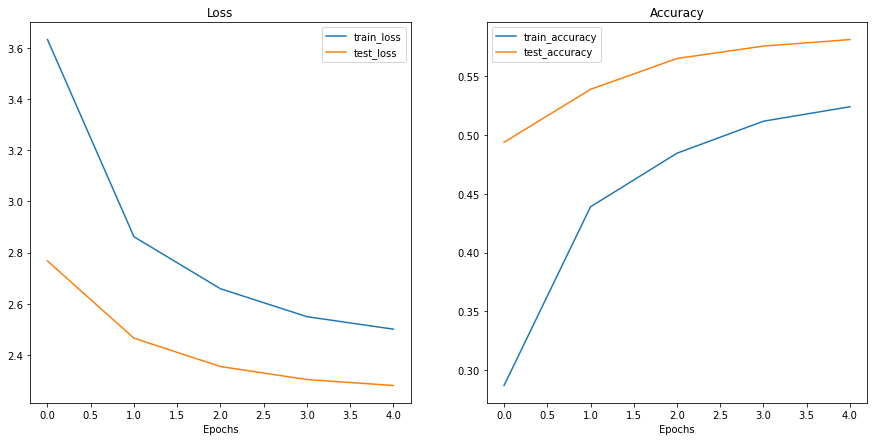

In [ ]:
from helper_functions import plot_loss_curves

# 查看 FoodVision Big 的 loss 曲线
plot_loss_curves(effnetb2_food101_results)

很好！！！

从曲线看，数据增强与 label smoothing 这两种正则化手段确实帮助抑制了过拟合（训练损失仍高于测试损失），这也说明模型还有继续学习并提升的空间。

### 10.7 保存并加载 FoodVision Big

现在我们已经训练出了迄今最大的模型，先保存起来，便于后续加载使用。

In [ ]:
from going_modular.going_modular import utils

# 创建模型文件名
effnetb2_food101_model_path = "09_pretrained_effnetb2_feature_extractor_food101_20_percent.pth"

# 保存 FoodVision Big 模型
utils.save_model(model=effnetb2_food101,
                 target_dir="models",
                 model_name=effnetb2_food101_model_path)

[INFO] Saving model to: models/09_pretrained_effnetb2_feature_extractor_food101_20_percent.pth


模型已保存！

继续前，先确认它可以被正确加载。

做法是先通过 `create_effnetb2_model(num_classes=101)` 创建模型实例（101 类）。

然后用 [`torch.nn.Module.load_state_dict()`](https://pytorch.org/docs/stable/generated/torch.nn.Module.html?highlight=load_state_dict#torch.nn.Module.load_state_dict) + [`torch.load()`](https://pytorch.org/docs/stable/generated/torch.load.html) 载入保存的 `state_dict()`。

In [ ]:
# 创建可兼容 Food101 的 EffNetB2 实例
loaded_effnetb2_food101, effnetb2_transforms = create_effnetb2_model(num_classes=101)

# 加载已保存模型的 state_dict()
loaded_effnetb2_food101.load_state_dict(torch.load("models/09_pretrained_effnetb2_feature_extractor_food101_20_percent.pth"))

<All keys matched successfully>

### 10.8 检查 FoodVision Big 模型大小

FoodVision Big 支持 101 类，而 FoodVision Mini 仅 3 类，类别数提升了约 33.6 倍。

那模型体积会变大多少？

我们来看看。

In [ ]:
from pathlib import Path

# 获取模型大小（字节）并转换为 MB
pretrained_effnetb2_food101_model_size = Path("models", effnetb2_food101_model_path).stat().st_size // (1024*1024) # 该除法将字节粗略转换为 MB
print(f"Pretrained EffNetB2 feature extractor Food101 model size: {pretrained_effnetb2_food101_model_size} MB")

Pretrained EffNetB2 feature extractor Food101 model size: 30 MB


看起来即使类别数大幅提升，模型体积变化仍不大（FoodVision Big 约 30 MB，FoodVision Mini 约 29 MB）。

原因是新增参数主要集中在最后一层（classifier head）。

两者共享相同的底层特征提取网络。

回到前面的模型摘要对比会更直观。

| **Model** | **Output shape (num classes)** | **Trainable parameters** | **Total parameters** | **Model size (MB)** |
| ----- | ----- | ----- | ----- | ----- |
| FoodVision Mini (EffNetB2 feature extractor) | 3 | 4,227 | 7,705,221 |  29 |
| FoodVision Big (EffNetB2 feature extractor) | 101 | 142,309 | 7,843,303 | 30 |


## 11. 将 FoodVision Big 模型做成可部署应用

我们已经在 Food101 的 20% 数据上训练并保存了 EffNetB2 模型。

与其让模型一直躺在文件夹里，不如部署它！

部署方式与 FoodVision Mini 一样：用 Gradio + Hugging Face Spaces。

首先创建 `demos/foodvision_big/` 目录用于放置 demo 文件，再创建 `demos/foodvision_big/examples` 存放示例图。

完成后目录结构如下：

```
demos/
  foodvision_big/
    09_pretrained_effnetb2_feature_extractor_food101_20_percent.pth
    app.py
    class_names.txt
    examples/
      example_1.jpg
    model.py
    requirements.txt
```

其中：

* `09_pretrained_effnetb2_feature_extractor_food101_20_percent.pth` 是训练好的 PyTorch 模型文件。
* `app.py` 包含 FoodVision Big 的 Gradio 应用逻辑。
* `class_names.txt` 保存 FoodVision Big 的全部类别名。
* `examples/` 保存 Gradio 示例图片。
* `model.py` 保存模型定义与 transforms。
* `requirements.txt` 保存运行依赖（如 `torch`、`torchvision`、`gradio`）。

In [ ]:
from pathlib import Path

# 创建 FoodVision Big demo 路径
foodvision_big_demo_path = Path("demos/foodvision_big/")

# 创建 FoodVision Big demo 目录
foodvision_big_demo_path.mkdir(parents=True, exist_ok=True)

# 创建 FoodVision Big demo 示例目录
(foodvision_big_demo_path / "examples").mkdir(parents=True, exist_ok=True)

### 11.1 下载示例图片并移动到 `examples` 目录

示例图我们使用经典的 [`pizza-dad` 图片](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/images/04-pizza-dad.jpeg)（我爸爸在吃披萨的照片）。

先用 `!wget` 从课程 GitHub 下载，再用 `!mv`（move）移动到 `demos/foodvision_big/examples`。

同时把训练好的 Food101 EffNetB2 模型从 `models/09_pretrained_effnetb2_feature_extractor_food101_20_percent.pth` 移动到 `demos/foodvision_big`。

In [ ]:
# 下载并移动示例图像
!wget https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/04-pizza-dad.jpeg 
!mv 04-pizza-dad.jpeg demos/foodvision_big/examples/04-pizza-dad.jpg

# 将训练好的模型移动到 FoodVision Big demo 目录（若已移动会报错）
!mv models/09_pretrained_effnetb2_feature_extractor_food101_20_percent.pth demos/foodvision_big

--2022-08-25 14:24:41--  https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/04-pizza-dad.jpeg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2874848 (2.7M) [image/jpeg]
Saving to: '04-pizza-dad.jpeg’

04-pizza-dad.jpeg   100%[===================>]   2.74M  7.85MB/s    in 0.3s    

2022-08-25 14:24:43 (7.85 MB/s) - '04-pizza-dad.jpeg’ saved [2874848/2874848]



### 11.2 将 Food101 类别名保存为文件（`class_names.txt`）

Food101 类别很多，没必要把整份列表硬编码在 `app.py` 里。

更好的做法是单独写入 `.txt` 文件，按需读取。

先回顾一下 `food101_class_names` 的内容。

In [ ]:
# 查看 Food101 前 10 个类别名
food101_class_names[:10]

['apple_pie',
 'baby_back_ribs',
 'baklava',
 'beef_carpaccio',
 'beef_tartare',
 'beet_salad',
 'beignets',
 'bibimbap',
 'bread_pudding',
 'breakfast_burrito']

很好，现在可以把类别名写入文本文件。

步骤是：先创建路径 `demos/foodvision_big/class_names.txt`，再用 Python `open()` 打开文件并逐行写入类别名。

理想格式如下：

```
apple_pie
baby_back_ribs
baklava
beef_carpaccio
beef_tartare
...
```

In [ ]:
# 创建 Food101 类别名文件路径
foodvision_big_class_names_path = foodvision_big_demo_path / "class_names.txt"

# 将 Food101 类别名列表写入文件
with open(foodvision_big_class_names_path, "w") as f:
    print(f"[INFO] Saving Food101 class names to {foodvision_big_class_names_path}")
    f.write("\n".join(food101_class_names)) # 每个类别名之间换一行

[INFO] Saving Food101 class names to demos/foodvision_big/class_names.txt


很好，接下来确认是否能正确读取。

可用 Python [`open()`](https://www.w3schools.com/python/ref_func_open.asp) 的读模式（`"r"`），再用 [`readlines()`](https://www.w3schools.com/python/ref_file_readlines.asp) 逐行读入 `class_names.txt`。

然后通过列表推导 + [`strip()`](https://www.w3schools.com/python/ref_string_strip.asp) 去掉换行，得到干净的类别名列表。

In [ ]:
# 打开 Food101 类别名文件并逐行读入列表
with open(foodvision_big_class_names_path, "r") as f:
    food101_class_names_loaded = [food.strip() for food in  f.readlines()]
    
# 查看回读后的前 5 个类别名
food101_class_names_loaded[:5]

['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare']

### 11.3 将 FoodVision Big 模型封装为 Python 脚本（`model.py`）

和 FoodVision Mini 一样，这里也创建一个脚本，用于实例化 EffNetB2 特征提取模型及其 transforms。

In [ ]:
%%writefile demos/foodvision_big/model.py
import torch
import torchvision

from torch import nn


def create_effnetb2_model(num_classes:int=3, 
                          seed:int=42):
    """创建 EfficientNetB2 特征提取器模型及其 transforms。

    Args:
        num_classes (int, optional): 分类头中的类别数。
            默认为 3。
        seed (int, optional): 随机种子。默认为 42。

    Returns:
        model (torch.nn.Module): EffNetB2 特征提取器模型。
        transforms (torchvision.transforms): EffNetB2 图像 transforms。
    """
    # 创建 EffNetB2 预训练权重、transforms 与模型
    weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT
    transforms = weights.transforms()
    model = torchvision.models.efficientnet_b2(weights=weights)

    # 冻结基础模型全部层
    for param in model.parameters():
        param.requires_grad = False

    # 设置随机种子并替换分类头（确保可复现）
    torch.manual_seed(seed)
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(in_features=1408, out_features=num_classes),
    )
    
    return model, transforms

Overwriting demos/foodvision_big/model.py


### 11.4 将 FoodVision Big Gradio 应用封装为 Python 脚本（`app.py`）

有了 FoodVision Big 的 `model.py`，接下来创建 `app.py`。

整体结构与 FoodVision Mini 的 `app.py` 基本一致，但要改这些点：

1. **导入与类别名设置** - `class_names` 不再是 pizza/steak/sushi，而是 Food101 全部类别，可从 `demos/foodvision_big/class_names.txt` 读取。
2. **模型与 transforms 准备** - `model` 的 `num_classes=101`（而非 `3`），并从 `"09_pretrained_effnetb2_feature_extractor_food101_20_percent.pth"` 加载权重。
3. **预测函数** - 与 FoodVision Mini `app.py` 保持一致。
4. **Gradio 应用** - 更新 `title`、`description`、`article` 以反映 FoodVision Big。

最后用 `%%writefile` 写入 `demos/foodvision_big/app.py`。

In [ ]:
%%writefile demos/foodvision_big/app.py
### 1. 导入依赖并设置类别名 ### 
import gradio as gr
import os
import torch

from model import create_effnetb2_model
from timeit import default_timer as timer
from typing import Tuple, Dict

# 设置类别名
with open("class_names.txt", "r") as f: # 从 class_names.txt 读取类别名
    class_names = [food_name.strip() for food_name in  f.readlines()]
    
### 2. 准备模型与 transforms ###    

# 创建模型
effnetb2, effnetb2_transforms = create_effnetb2_model(
    num_classes=101, # 也可使用 len(class_names)
)

# 加载已保存权重
effnetb2.load_state_dict(
    torch.load(
        f="09_pretrained_effnetb2_feature_extractor_food101_20_percent.pth",
        map_location=torch.device("cpu"),  # 加载到 CPU
    )
)

### 3. 预测函数 ###

# 创建预测函数
def predict(img) -> Tuple[Dict, float]:
    """对输入图像做 transform 并预测，返回预测结果与耗时。
    """
    # 开始计时
    start_time = timer()
    
    # 对目标图像做 transform 并添加 batch 维度
    img = effnetb2_transforms(img).unsqueeze(0)
    
    # 将模型切到评估模式并开启推理模式
    effnetb2.eval()
    with torch.inference_mode():
        # 将图像送入模型，并把 logits 转成预测概率
        pred_probs = torch.softmax(effnetb2(img), dim=1)
    
    # 为每个类别创建“类别名: 概率”字典（Gradio 输出要求）
    pred_labels_and_probs = {class_names[i]: float(pred_probs[0][i]) for i in range(len(class_names))}
    
    # 计算预测耗时
    pred_time = round(timer() - start_time, 5)
    
    # 返回预测字典与预测耗时
    return pred_labels_and_probs, pred_time

### 4. Gradio 应用 ###

# 创建 title、description 和 article 字符串
title = "FoodVision Big 🍔👁"
description = "An EfficientNetB2 feature extractor computer vision model to classify images of food into [101 different classes](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/extras/food101_class_names.txt)."
article = "Created at [09. PyTorch Model Deployment](https://www.learnpytorch.io/09_pytorch_model_deployment/)."

# 从 "examples/" 目录创建示例列表
example_list = [["examples/" + example] for example in os.listdir("examples")]

# 创建 Gradio 界面
demo = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="pil"),
    outputs=[
        gr.Label(num_top_classes=5, label="Predictions"),
        gr.Number(label="Prediction time (s)"),
    ],
    examples=example_list,
    title=title,
    description=description,
    article=article,
)

# 启动应用
demo.launch()

Overwriting demos/foodvision_big/app.py


### 11.5 为 FoodVision Big 创建依赖文件（`requirements.txt`）

现在只差一个 `requirements.txt`，用来告诉 Hugging Face Space 运行 FoodVision Big 所需依赖。

In [84]:
%%writefile demos/foodvision_big/requirements.txt
torch==1.12.0
torchvision==0.13.0
gradio==3.1.4

Overwriting demos/foodvision_big/requirements.txt


### 11.6 下载 FoodVision Big 应用文件

部署 FoodVision Big 到 Hugging Face 所需文件已齐全，接下来把它们打包并下载。

流程与上面 [section 9.1](https://www.learnpytorch.io/09_pytorch_model_deployment/#91-downloading-our-foodvision-mini-app-files) 的 FoodVision Mini 完全一致。

In [ ]:
# 压缩 foodvision_big 文件夹并排除部分文件
!cd demos/foodvision_big && zip -r ../foodvision_big.zip * -x "*.pyc" "*.ipynb" "*__pycache__*" "*ipynb_checkpoints*"

# 下载压缩后的 FoodVision Big 应用（若在 Google Colab 中运行）
try:
    from google.colab import files
    files.download("demos/foodvision_big.zip")
except:
    print("Not running in Google Colab, can't use google.colab.files.download()")

updating: 09_pretrained_effnetb2_feature_extractor_food101_20_percent.pth (deflated 8%)
updating: app.py (deflated 54%)
updating: class_names.txt (deflated 48%)
updating: examples/ (stored 0%)
updating: flagged/ (stored 0%)
updating: model.py (deflated 56%)
updating: requirements.txt (deflated 4%)
updating: examples/04-pizza-dad.jpg (deflated 0%)
Not running in Google Colab, can't use google.colab.files.download()


### 11.7 将 FoodVision Big 应用部署到 Hugging Face Spaces

太漂亮了！

现在该让本课程最大的模型真正上线了。

我们把 FoodVision Big Gradio demo 部署到 Hugging Face Spaces，这样既可交互测试，也能分享给其他人体验。

> **Note:** 上传到 Hugging Face Spaces 的方式有多种，见 [官方文档](https://huggingface.co/docs/hub/repositories-getting-started#getting-started-with-repositories)。下面采用“把 Hugging Face 当作 git 仓库”的方式；你也可以用 [网页界面](https://huggingface.co/docs/hub/repositories-getting-started#adding-files-to-a-repository-web-ui) 或 [`huggingface_hub` 库](https://huggingface.co/docs/huggingface_hub/index)。

好消息是，FoodVision Mini 已经走过一次同样流程，这里只需按 FoodVision Big 版本替换：

1. [注册](https://huggingface.co/join) Hugging Face 账号。
2. 进入个人主页并 [点击 "New Space"](https://huggingface.co/new-space) 创建新 Space。
    * **Note:** Hugging Face 的 Space 也就是一个“代码仓库（repo）”。
3. 给 Space 命名，例如我的叫 `mrdbourke/foodvision_big`，地址是：https://huggingface.co/spaces/mrdbourke/foodvision_big
4. 选择许可证（我用 [MIT](https://opensource.org/licenses/MIT)）。
5. Space SDK 选 Gradio。
   * **Note:** 也可选 Streamlit，但本应用基于 Gradio，所以继续选 Gradio。
6. 选择 Space 公有或私有（我选公有）。
7. 点击 "Create Space"。
8. 本地克隆仓库：`git clone https://huggingface.co/spaces/[YOUR_USERNAME]/[YOUR_SPACE_NAME]`。
    * **Note:** 也可在 "Files and versions" 标签页直接上传。
9. 将下载后的 `foodvision_big` 目录内容复制/移动到克隆仓库目录。
10. 上传大文件（如 >10MB，包含模型文件）前需 [安装 Git LFS](https://git-lfs.github.com/)（Large File Storage）。
11. 安装后执行 `git lfs install` 启用。
12. 在 `foodvision_big` 目录中通过 Git LFS 追踪大文件：`git lfs track "*.file_extension"`。
    * 对模型文件执行：`git lfs track "09_pretrained_effnetb2_feature_extractor_food101_20_percent.pth"`。
    * **Note:** 若上传图片报错，也可能要走 LFS，例如：`git lfs track "examples/04-pizza-dad.jpg"`。
13. 追踪 `.gitattributes`（从 Hugging Face 克隆后通常自动生成，用于确保大文件走 LFS）。可参考 [FoodVision Big 的 `.gitattributes` 示例](https://huggingface.co/spaces/mrdbourke/foodvision_big/blob/main/.gitattributes)。
    * `git add .gitattributes`
14. 添加其余 `foodvision_big` 文件并提交：
    * `git add *`
    * 示例提交：`git commit -m "first commit"`
15. 推送到 Hugging Face：
    * `git push`
16. 等待约 3-5 分钟完成构建（后续通常更快），应用即可上线。

如果一切顺利，FoodVision Big Gradio demo 就能开始分类了！

我的在线版本在这里：https://huggingface.co/spaces/mrdbourke/foodvision_big/

同样也可以通过 [iframe](https://gradio.app/sharing_your_app/#embedding-with-iframes) 在 notebook 中内嵌，配合 [`IPython.display.IFrame`](https://ipython.readthedocs.io/en/stable/api/generated/IPython.display.html#IPython.display.IFrame) 和格式链接：`https://hf.space/embed/[YOUR_USERNAME]/[YOUR_SPACE_NAME]/+`。

In [ ]:
# 导入用于在 notebook 中嵌入页面的 IFrame 组件
from IPython.display import IFrame

# 以内嵌 iFrame 的方式展示 FoodVision Big Gradio demo
IFrame(src="https://hf.space/embed/mrdbourke/foodvision_big/+", width=900, height=750)

是不是很酷！

我们已经从“用 PyTorch 拟合一条直线”，走到了“构建全球用户都能访问的计算机视觉应用”。

## 关键收获

* **部署和训练同样重要。** 当你训练出可用模型后，第一反应应是：如何部署并让他人可访问？部署让你在真实世界中测试模型，而不只是在私有训练/测试集上。
* **机器学习模型部署的三个核心问题：**
    1. 目标使用场景是什么（模型需要多准、多快）？
    2. 模型运行在哪里（端侧还是云端）？
    3. 推理如何执行（在线还是离线）？
* **部署方式很多，但先从简单方案开始。** 当前常见且高效的路径是：用 Gradio 构建 demo，再托管到 Hugging Face Spaces。先跑通，再扩展。
* **持续实验，不要停止。** 你的模型需求会随时间变化：数据会变、任务会变、架构也会迭代。一次部署不是终点，而是持续改进的起点。
    * 因此，完成一次部署非常重要，但更重要的是持续更新它。
* **模型部署属于 MLOps 工程实践的一部分。** MLOps 是 DevOps 在机器学习场景的延伸，涵盖数据采集存储、数据预处理、模型部署、监控、版本管理等。该领域发展很快，但已有很多优质学习资源，可参考 [PyTorch Extra Resources](https://www.learnpytorch.io/pytorch_extra_resources/#resources-for-machine-learning-and-deep-learning-engineering)。

## 练习

以下练习均围绕上方代码实践展开。

你可以结合各小节内容，或参考链接资源来完成。

**资源：**

* [09 章练习模板 notebook](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/extras/exercises/09_pytorch_model_deployment_exercises.ipynb)。
* [09 章参考解答 notebook](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/extras/solutions/09_pytorch_model_deployment_exercise_solutions.ipynb)（建议先独立完成再看）。
    * 也可观看 YouTube 上的 [解题视频 walkthrough](https://youtu.be/jOX5ZCkWO-0)（包含报错与排查过程）。

1. 在测试集上分别用两个特征提取器模型，并在 GPU（`device="cuda"`）上做预测计时。比较 GPU 与 CPU 推理耗时差异：GPU 是否能缩小 ViT 与 EffNetB2 的速度差距？
    * 相关代码见 [section 5](https://www.learnpytorch.io/09_pytorch_model_deployment/#5-making-predictions-with-our-trained-models-and-timing-them) 与 [section 6](https://www.learnpytorch.io/09_pytorch_model_deployment/#6-comparing-model-results-prediction-times-and-size)。
2. ViT 特征提取器参数更多，学习容量看起来高于 EffNetB2；在 Food101 全类别 20% 子集上表现如何？
    * 参照 [section 10](https://www.learnpytorch.io/09_pytorch_model_deployment/#10-creating-foodvision-big) 的流程，在 20% Food101 上训练 5 个 epoch。
3. 使用练习 2 的 ViT 模型在 20% Food101 测试集上预测，找出“错得最离谱”的样本。
    * 即预测概率最高但标签错误的样本。
    * 并写 1-2 句话分析可能原因。
4. 不只评估 20% 测试子集，改为在完整 Food101 测试集上评估 ViT，表现如何？
    * 是否超过原 Food101 论文 56.4% 的准确率？
5. 访问 [Paperswithcode.com](https://paperswithcode.com/) 查找当前 Food101 上的最佳模型。
    * 它使用了什么模型架构？
6. 列出我们部署的 FoodVision 模型可能出现的 1-3 个失效点，并给出潜在改进方案。
    * 例如：如果有人上传非食物图片到 FoodVision Mini，会发生什么？
7. 从 [`torchvision.datasets`](https://pytorch.org/vision/stable/datasets.html) 任意选一个数据集，再从 [`torchvision.models`](https://pytorch.org/vision/stable/models.html) 选一个模型（可复用 EffNetB2 或 ViT）训练 5 个 epoch，并将其部署为 Hugging Face Spaces 上的 Gradio 应用。
    * 可以优先选择更小数据集，或先做更小比例划分，缩短训练时间。
    * 非常欢迎在 Discord 或课程 [GitHub Discussions](https://github.com/mrdbourke/pytorch-deep-learning/discussions) 分享你的部署成果。

## 课外拓展

* 机器学习模型部署通常更偏工程挑战，而不只是纯模型挑战。可参考 [PyTorch Extra Resources 的机器学习工程部分](https://www.learnpytorch.io/pytorch_extra_resources/#resources-for-machine-learning-and-deep-learning-engineering)。
    * 其中推荐了很多资源，例如 Chip Huyen 的书 [*Designing Machine Learning Systems*](https://www.amazon.com/Designing-Machine-Learning-Systems-Production-Ready/dp/1098107969)（尤其第 7 章部署）以及 Goku Mohandas 的 [Made with ML MLOps 课程](https://madewithml.com/#mlops)。
* 当你开始做更多项目后，会越来越频繁地使用 Git（以及可能的 GitHub）。推荐 freeCodeCamp 的 [*Git and GitHub for Beginners - Crash Course*](https://youtu.be/RGOj5yH7evk)。
* 我们目前只触及了 Gradio 的一部分能力。建议阅读 [完整文档](https://gradio.app/docs/)，重点包括：
    * 各类 [输入/输出组件](https://gradio.app/docs/#components)。
    * 用于复杂工作流的 [Gradio Blocks API](https://gradio.app/docs/#blocks)。
    * Hugging Face Course 关于 [Gradio 与 Hugging Face 配合使用](https://huggingface.co/course/chapter9/1) 的章节。
* 边缘设备并不只指手机，也包括 Raspberry Pi 等小型计算机。PyTorch 团队提供了一个很棒的教程，演示如何把模型部署到树莓派：[教程链接](https://pytorch.org/tutorials/intermediate/realtime_rpi.html)。
* 如果你想系统学习 AI/ML 产品设计，推荐 [Google 的 People + AI Guidebook](https://pair.withgoogle.com/guidebook)。我很喜欢其中关于 [设定正确预期](https://pair.withgoogle.com/guidebook/patterns#set-the-right-expectations) 的部分。
    * 我也在 [Machine Learning Monthly 2021 年 4 月期](https://zerotomastery.io/blog/machine-learning-monthly-april-2021/) 汇总过类似资源（包括 Apple、Microsoft 等公司的指南）。
* 如果你希望进一步提升 CPU 推理速度，可以了解 [TorchScript](https://pytorch.org/tutorials/beginner/Intro_to_TorchScript_tutorial.html)、[ONNX](https://pytorch.org/docs/stable/onnx.html)（Open Neural Network Exchange）和 [OpenVINO](https://docs.openvino.ai/latest/notebooks/102-pytorch-onnx-to-openvino-with-output.html)。从纯 PyTorch 切到 ONNX/OpenVINO，我见过约 2x+ 的性能提升。
* 若要把模型做成可扩展 API 服务，可参考 [TorchServe](https://pytorch.org/serve/)。
* 关于“为什么把模型推理从云端迁到浏览器/端侧（减少网络传输时延）很有价值”，推荐 Jo Kristian Bergum 的文章：[*Moving ML Inference from the Cloud to the Edge*](https://bergum.medium.com/moving-ml-inference-from-the-cloud-to-the-edge-d6f98dbdb2e3)。